In [2]:
from cell_labelling_functions import *

In [3]:
######### INPUTS ###########
# List of WSI paths
# WSI_paths = [
#     r'\\169.254.138.20\Andre\data\Stardist\Healthy nPOD\nondiabetic'
#     ]
# # date = '12_27_2024' # date of the segmentation
# date = '1_1_2025' # date of the segmentation
#     ]
WSI_paths = [
    r'\\kittyserverdw\Andre_kit\data\BTC\H1'
    ]
# # date = '12_27_2024' # date of the segmentation
# date = '5_3_2025' # date of the segmentation
date = '8_28_2025' # date of the segmentation
saveMASKS =0 # save segmented cells masks
target_resolution=1 # mask resolution 1->10x
RGBfeatures=1 # do you want to extract rgb features from contours 1-yes,0-no
gj=1 # do the geojson countours of the segmented cells, 1 if yes, 0 if no
inverse=0

# Change this to the model you want to load
# model_name = "panin_healthy"  #"pdac" "panin" "panin_healthy"  "monkey"  "fallopian_tube"
model_name = "pdac"  #"pdac" "panin" "panin_healthy"  "monkey"  "fallopian_tube"

############################
for WSI_path in WSI_paths:
    # Define output paths
    out_pth = os.path.join(WSI_path, f'StarDist_{date}_{model_name}')
    out_pth_json = os.path.join(out_pth, 'json')
    out_pth_tif = os.path.join(out_pth, 'stardist_masks')
    output_pixres = os.path.join(WSI_path,'segmentation_analysis', 'pix_res_info')
    outpthpkl = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')
    outpthmat=os.path.join(outpthpkl,'mat')
    out_pth_contours = os.path.join(out_pth_json, 'geojsons', '32_polys_20x')
    out_pth_analysis = os.path.join(out_pth, 'analysis')
    
    # Create directories if they don't exist
    for path in [out_pth, out_pth_json, out_pth_tif,output_pixres,outpthpkl,outpthmat,out_pth_contours,out_pth_analysis]:
        os.makedirs(path, exist_ok=True)
    
    print(out_pth_json)    

\\kittyserverdw\Andre_kit\data\BTC\H1\StarDist_8_28_2025_pdac\json


In [3]:
out_pth_analysis_stats = os.path.join(out_pth_analysis, 'stats')
out_pth_analysis_boxplots = os.path.join(out_pth_analysis, 'boxplots')
out_pth_analysis_histograms = os.path.join(out_pth_analysis, 'histograms')
out_pth_analysis_scatterplots = os.path.join(out_pth_analysis, 'scatterplots')
out_pth_analysis_violin = os.path.join(out_pth_analysis, 'violinplots')
out_pth_analysis_densitycurves = os.path.join(out_pth_analysis, 'density_curves')
out_pth_analysis_heatmap = os.path.join(out_pth_analysis, 'heatmap')
    
# Create directories if they don't exist
for path in [out_pth_analysis_stats,out_pth_analysis_boxplots,out_pth_analysis_histograms,
             out_pth_analysis_scatterplots,out_pth_analysis_violin,out_pth_analysis_densitycurves,out_pth_analysis_heatmap]:
    os.makedirs(path, exist_ok=True)

In [ ]:
out_pth_analysis_violin

In [ ]:
# path 10x H&E stained images
# pth10x=r'\\169.254.138.20\Andre\data\Stardist\Healthy nPOD\nondiabetic\10x'
# pth10x=r'\\kittyserverdw\Andre_kit\data\BTC\H15\10x_python'
pth10x=os.path.join(WSI_path,'10x_python')
print(pth10x)

# path to the 10x segmented images
# pth10xsegmented=os.path.join(pth10x, 'classification_12152024_HE')
# pth10xsegmented=os.path.join(pth10x, 'classification_10_5_2023') # BTC
pth10xsegmented=os.path.join(pth10x, 'classification_6_11_2023') # BTC
# pth10xsegmented=os.path.join(pth10x, 'classification_01_25_2024_10x_PNET')

# Class names and colors
# class_names = ["islets of Langerhans", "pancreatic ducts", "blood vessels", "fat",
#                "acini", "stroma", "background", "nerves"]
# class_colors = [
#     [70, 220, 220], [80, 70, 220], [70, 180, 80], [220, 220, 80],
#     [130, 50, 190], [240, 180, 230], [255, 255, 255], [160, 130, 40]
# ]
class_names = ["tumor", "stroma", "immune", "vasculature", "fat", "white", "acini", "islets", "nerve", "duct"]
class_colors = [
    [253, 146, 87],    # 1 tumor (orange)
    [224, 187, 228],   # 2 stroma (light pink)
    [0, 30, 30],       # 3 immune (black)
    [234, 0, 0],       # 4 vasculature (red)
    [255, 255, 0],     # 5 fat (yellow)
    [255, 255, 255],   # 6 white (white)
    [149, 35, 184],    # 7 acini (purple)
    [247, 243, 203],   # 8 islets (light beige)
    [205, 235, 204],   # 9 nerve (light green)
    [0, 0, 255]        # 10 duct (blue)
]
WS_class=6  # Class 6 = "white" (exclude from plotting)

# class_names = ["islets_of_Langerhans", "normal_epithelium", "smooth_muscle", "fat", "acini", "stroma", "nontissue", "PanIN", "nerves", "immune_hotspots", "endothelium", "PanNET"]
# class_colors=[
#      [70,220,220],  # 1 islet
#      [80,70,220],  # 2 duct
#      [70,180,80],  # 3 smooth muscle
#      [220,220,80],  # 4 fat
#      [130,50,190],  # % 5 acinus
#      [240,180,230],  # 6 connective tissue
#      [255,255,255],  # 7 whitespace
#      [210,80,75 ],  # 8 PanIN
#      [160,130,40],  # 9 nerves
#      [50,50,50],  # 10 immune
#      [160,30,120],  # 11 endothelium
#      [15,80,110]   # 12 PanNET
# ]
class_colors_norm = [[c / 255 for c in color] for color in class_colors]

# pixel resolution of the segmented images from first matfile .mat in output_pixres
pthmatfiles = get_sorted_files(output_pixres, '.mat')
mat = loadmat(pthmatfiles[0])
res = mat['pix_res'][0]  # Extract the 'pix_res' array

# Extract resolution values from the nested structure
pixelres = float(res[0][0][0])

pthjsonfiles = get_sorted_files(out_pth_json, '.json')
WSIs = get_sorted_files(WSI_path, '.svs','.ndpi')

# Check which files have already been processed
print("Checking which files have been processed...")
out_pth_contours = os.path.join(out_pth_json, 'geojsons', '32_polys_20x_labels')
os.makedirs(out_pth_contours, exist_ok=True)

# Get base names (without extension) for comparison
json_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in pthjsonfiles}
pkl_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in get_sorted_files(outpthpkl, '.pkl')} if os.path.exists(outpthpkl) else {}
geojson_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in get_sorted_files(out_pth_contours, '.geojson')} if os.path.exists(out_pth_contours) else {}
mat_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in get_sorted_files(outpthmat, '.mat')} if os.path.exists(outpthmat) else {}

# Find which JSON files need processing
json_files_needing_geojson = [json_basenames[nm] for nm in json_basenames if nm not in geojson_basenames]
json_files_needing_pkl = [json_basenames[nm] for nm in json_basenames if nm not in pkl_basenames]
pkl_files_needing_mat = [pkl_basenames[nm] for nm in pkl_basenames if nm not in mat_basenames]

print(f"Total JSON files: {len(json_basenames)}")
print(f"  - Already have geojson: {len(geojson_basenames)}")
print(f"  - Need geojson: {len(json_files_needing_geojson)}")
print(f"  - Already have pkl: {len(pkl_basenames)}")
print(f"  - Need pkl: {len(json_files_needing_pkl)}")
print(f"  - Already have mat: {len(mat_basenames)}")
print(f"  - Need mat: {len(pkl_files_needing_mat)}")

# Get dfs list for mat conversion (only existing pkl files)
dfs = get_sorted_files(outpthpkl, '.pkl') if os.path.exists(outpthpkl) else []

In [ ]:
# make geojson contours of the segmented cells with respective classes
# Only process if there are files needing geojson
if len(json_files_needing_geojson) > 0:
    print(f"\nProcessing {len(json_files_needing_geojson)} files for geojson generation...")
    make_geojson_contours_with_classes(
        out_pth_json= out_pth_json,
        ds_amt=1,
        ds_mask=1/pixelres, # 1/0.4416->10x usually;
        class_names=class_names,
        class_colors=class_colors_norm,
        gj=1,
        pth10xsegmented=pth10xsegmented,
        step=50
    )
else:
    print("\nAll geojson files already exist. Skipping geojson generation.")

In [ ]:
# EXTRACTS FEATURES FROM JSON CONTOURS AND SAVES THEM IN A PICKLE DATAFRAME
# Computes also the RGB average intensities inside of each contour 
# If features exist without classes, just add class labels (faster than re-extraction)

# ========== PARAMETERS ==========
vis_check_interval = 50  # Check visualization every N images (set to 0 to disable)
# =================================

outpthpkl_no_classes = os.path.join(out_pth, 'stardist_feature_df_pickles')
outpthpkl_with_classes = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')

# Process pkl files: add class labels to existing files or identify files needing full extraction
files_processed, remaining_json_files = process_pkl_files_with_class_labels(
    outpthpkl_no_classes=outpthpkl_no_classes,
    outpthpkl_with_classes=outpthpkl_with_classes,
    pth10xsegmented=pth10xsegmented,
    pixelres=pixelres,
    class_names=class_names,
    class_colors=class_colors,
    json_basenames=json_basenames,
    pthjsonfiles=pthjsonfiles,
    WSIs=WSIs,
    vis_check_interval=vis_check_interval,
    out_pth_analysis=out_pth_analysis
)

# Process remaining JSON files that need full feature extraction
if len(remaining_json_files) > 0:
    print(f"\n{len(remaining_json_files)} JSON files still need full feature extraction...")
    json_files_needing_pkl_set = set(remaining_json_files)
    json_files_needing_pkl_filtered = []
    WSIs_needing_pkl = []
    for i, json_file in enumerate(pthjsonfiles):
        if json_file in json_files_needing_pkl_set:
            json_files_needing_pkl_filtered.append(json_file)
            WSIs_needing_pkl.append(WSIs[i])
    
    print(f"Extracting features for {len(json_files_needing_pkl_filtered)} files...")
    make_RGBfeatures_df_pkl_from_contours_jsons_with_classes(
        json_files_needing_pkl_filtered, 
        WSIs_needing_pkl, 
        outpthpkl_with_classes,
        segmented_image_dir=pth10xsegmented, 
        ds_mask=1/pixelres,
        class_names=class_names
    )
else:
    print("\n✓ All files have been processed!")

In [ ]:
# MAKE LIST OF FEATURES DF PKL FILES AND SAVES THEM AS MAT FILES 
# Re-check pkl files in case new ones were created during processing
if os.path.exists(outpthpkl):
    dfs = get_sorted_files(outpthpkl, '.pkl')
    if len(dfs) > 0:
        print(f"\nConverting {len(dfs)} pkl files to mat format...")
        # Get just the filenames (not full paths) for the function
        dfs_filenames = [os.path.basename(f) for f in dfs]
        featuresdf_pkl2mat(outpthpkl, outpthmat, dfs_filenames)
    else:
        print("\nNo pkl files found. Skipping mat conversion.")
else:
    print("\nPkl directory does not exist. Skipping mat conversion.")

In [ ]:
# Summary of processing status
print("\n" + "="*60)
print("PROCESSING SUMMARY")
print("="*60)

# Re-check all files after processing
if os.path.exists(outpthpkl):
    final_pkl_files = get_sorted_files(outpthpkl, '.pkl')
    final_pkl_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in final_pkl_files}
else:
    final_pkl_basenames = {}

if os.path.exists(out_pth_contours):
    final_geojson_files = get_sorted_files(out_pth_contours, '.geojson')
    final_geojson_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in final_geojson_files}
else:
    final_geojson_basenames = {}

if os.path.exists(outpthmat):
    final_mat_files = get_sorted_files(outpthmat, '.mat')
    final_mat_basenames = {os.path.splitext(os.path.basename(f))[0]: f for f in final_mat_files}
else:
    final_mat_basenames = {}

print(f"\nTotal JSON files: {len(json_basenames)}")
print(f"  ✓ Geojson files: {len(final_geojson_basenames)} / {len(json_basenames)} ({100*len(final_geojson_basenames)/len(json_basenames):.1f}%)")
print(f"  ✓ Pkl files: {len(final_pkl_basenames)} / {len(json_basenames)} ({100*len(final_pkl_basenames)/len(json_basenames):.1f}%)")
print(f"  ✓ Mat files: {len(final_mat_basenames)} / {len(final_pkl_basenames) if final_pkl_basenames else 0} ({100*len(final_mat_basenames)/len(final_pkl_basenames) if final_pkl_basenames else 0:.1f}%)")

if len(final_pkl_basenames) == len(json_basenames):
    print("\n✓ All JSON files have been processed into pkl files!")
else:
    missing_pkl = len(json_basenames) - len(final_pkl_basenames)
    print(f"\n⚠ {missing_pkl} JSON files still need pkl processing")

print("="*60)

## Load pkl dataframe with all cell features

In [ ]:
sns.set(style="ticks")
# Convert RGB colors to HEX
class_colors_hex = rgb_to_hex(class_colors)
# Create a palette dictionary mapping class names to HEX colors
palette = dict(zip(class_names, class_colors_hex))
# Class Mapping: Integer labels to Class Names
# class_mapping = {
#     1: "islets of Langerhans",
#     2: "pancreatic ducts",
#     3: "blood vessels",
#     4: "fat",
#     5: "acini",
#     6: "stroma",
#     7: "background",
#     8: "nerves"
# }
class_mapping = {
    1: "tumor",
    2: "stroma",
    3: "immune",
    4: "vasculature",
    5: "fat",
    6: "white",
    7: "acini",
    8: "islets",
    9: "nerve",
    10: "duct"
}

WS_class=6  # Class 6 = "white" (exclude from plotting)

In [ ]:
# outpthpkl = os.path.join(out_pth, 'stardist_feature_df_pickles')
outpthpkl = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')
# Load and combine data
df = load_data(outpthpkl)

In [ ]:
print(outpthpkl)

In [ ]:
np.shape(df)

In [ ]:
df.head()

In [ ]:
# Define numerical features to analyze (exclude 'slide_num' and 'class_name')
numerical_features = [col for col in df.columns if col not in ['slide_num', 'class_name', 'Centroid_x', 'Centroid_y']]

In [ ]:
df.columns

In [ ]:
numerical_features

## Bulk nuclear feature quantifications 


In [ ]:
def plot_violin_shifted(df, feature, class_mapping, palette, output_dir, WS_class, plot=1):
    """
    Create a violin plot for a given feature across classes (excluding class 7) sorted by median descending.
    Also computes and saves statistics—including coefficient of variation—to CSV and Excel files.

    Parameters:
        df (pd.DataFrame): DataFrame with 'class_name' and the feature.
        feature (str): The feature to plot.
        class_mapping (dict): Mapping from class integers to class names.
        palette (dict): Mapping from class names to colors.
        output_dir (str): Directory to save the plot and statistics files.
        plot (int): 1 to plot and save the violin plot; 0 to skip plotting.
    """
    resolution = 0.504  # microns per pixel
    os.makedirs(output_dir, exist_ok=True)

    # Filter and map class names
    filtered_df = df[df['class_name'] != WS_class].copy()
    filtered_df['class_name_str'] = filtered_df['class_name'].map(class_mapping)
    filtered_df = filtered_df.dropna(subset=['class_name_str'])

    # Convert pixel-based metrics to microns if applicable
    pixel_features = ['Area', 'Perimeter', 'maximum_radius', 'mean_radius',
                      'median_radius', 'minor_axis_length', 'major_axis_length']
    if feature in pixel_features:
        if feature == 'Area':
            filtered_df[feature] = filtered_df[feature] * (resolution ** 2)
        else:
            filtered_df[feature] = filtered_df[feature] * resolution

    # Calculate statistics and convert them if needed
    stats_df = calculate_statistics(df, feature, class_mapping)
    if feature in pixel_features:
        factor = resolution ** 2 if feature == 'Area' else resolution
        stats_df['mean']   = stats_df['mean'] * factor
        stats_df['std']    = stats_df['std'] * factor
        stats_df['median'] = stats_df['median'] * factor
        stats_df['min']    = stats_df['min'] * factor
        stats_df['max']    = stats_df['max'] * factor
        # Note: coef_var remains the same because it is a ratio

    # Save statistics to CSV and Excel (CV is included)
    stats_csv_path = os.path.join(output_dir, f'stats_{feature}.csv')
    stats_df.to_csv(stats_csv_path, index=False)
    print(f"Statistics saved to {stats_csv_path}")

    stats_excel_path = os.path.join(output_dir, f'stats_{feature}.xlsx')
    stats_df.to_excel(stats_excel_path, index=False)
    print(f"Statistics saved to {stats_excel_path}")

    # If plotting is requested, create and save the violin plot
    if plot:
        # Sort classes by median descending for plotting
        median_per_class = filtered_df.groupby('class_name_str')[feature].median().sort_values(ascending=False)
        sorted_classes = median_per_class.index.tolist()

        sns.set(style="ticks")
        plt.figure(figsize=(12, 8))

        # Create violin plot
        ax = sns.violinplot(
            x='class_name_str',
            y=feature,
            data=filtered_df,
            order=sorted_classes,
            hue='class_name_str',
            palette=palette,
            inner='quartile',
            width=0.35,
            linewidth=2.5,
            legend=False
        )

        # Plot shifted data points
        shift = 0.5
        for i, class_name in enumerate(sorted_classes):
            subset = filtered_df[filtered_df['class_name_str'] == class_name]
            x = np.random.normal(loc=i, scale=0.05, size=len(subset)) + shift
            scatter_color = palette.get(class_name, 'black')
            plt.scatter(x, subset[feature], color=scatter_color, s=0.5, alpha=0.3)

        sns.despine()
        plt.xticks(rotation=45, fontsize=18)
        plt.yticks(fontsize=18)
        plt.title(f'Violin Plot of {feature} by Class', fontsize=20)
        plt.xlabel('Class Name', fontsize=20)
        plt.ylabel(f'{feature} ({"µm²" if feature=="Area" else "µm"})', fontsize=20)
        plt.tight_layout()

        plot_path = os.path.join(output_dir, f'violin_{feature}.png')
        plt.savefig(plot_path, dpi=300)
        plt.close()
        print(f"Violin plot saved to {plot_path}")

                # Create and save log-scale version
        # Filter out zero/negative values for log scale
        filtered_df_log = filtered_df[filtered_df[feature] > 0].copy()
        
        if len(filtered_df_log) > 0:
            # Re-sort classes by median for log plot
            median_per_class_log = filtered_df_log.groupby('class_name_str')[feature].median().sort_values(ascending=False)
            sorted_classes_log = median_per_class_log.index.tolist()
            
            sns.set(style="ticks")
            plt.figure(figsize=(12, 8))
            
            # Create violin plot with log scale
            ax = sns.violinplot(
                x='class_name_str',
                y=feature,
                data=filtered_df_log,
                order=sorted_classes_log,
                hue='class_name_str',
                palette=palette,
                inner='quartile',
                width=0.35,
                linewidth=2.5,
                legend=False
            )
            # Set y-axis to log scale
            ax.set_yscale('log')
            
            # Plot shifted data points
            shift = 0.5
            for i, class_name in enumerate(sorted_classes_log):
                subset = filtered_df_log[filtered_df_log['class_name_str'] == class_name]
                if len(subset) > 0:
                    x = np.random.normal(loc=i, scale=0.05, size=len(subset)) + shift
                    scatter_color = palette.get(class_name, 'black')
                    plt.scatter(x, subset[feature], color=scatter_color, s=0.5, alpha=0.3)
            
            sns.despine()
            plt.xticks(rotation=45, fontsize=18)
            plt.yticks(fontsize=18)
            plt.title(f'Violin Plot of {feature} by Class (Log Scale)', fontsize=20)
            plt.xlabel('Class Name', fontsize=20)
            
            # Scientific notation for y-axis label with log scale indication
            unit = "µm²" if feature == "Area" else "µm"
            # plt.ylabel(f'Log₁₀({feature} ({unit}))', fontsize=20)
            plt.ylabel(f'$\\log_{{10}}$({feature} ({unit}))', fontsize=20)
            plt.tight_layout()
            
            plot_path_log = os.path.join(output_dir, f'violin_{feature}_log.png')
            plt.savefig(plot_path_log, dpi=300)
            plt.close()
            print(f"Log-scale violin plot saved to {plot_path_log}")
        else:
            print(f"  Warning: No positive values found for {feature}, skipping log-scale plot")
            
    else:
        print("Plotting skipped..")


In [ ]:
print("Colors of each tissue type:")
for tissue, color in palette.items():
    print(f"{tissue}: {color}")

# Plot the color for each tissue type as a swatch
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 2))
for idx, (tissue, color) in enumerate(palette.items()):
    ax.bar(idx, 1, color=color)
ax.set_xticks(range(len(palette)))
ax.set_xticklabels(palette.keys(), rotation=45, ha='right')
ax.set_yticks([])
plt.tight_layout()
plt.show()



In [ ]:
# plot_violin_shifted(df, numerical_features, class_mapping, palette, out_pth_analysis_violin)
# Iterate over numerical features and plot
for feature in numerical_features:
    # plot_violin_shifted(df, feature, class_mapping, palette, out_pth_analysis_violin,plot=1)
    plot_violin_shifted(df, feature, class_mapping, palette, out_pth_analysis_violin, WS_class,plot=1)

In [ ]:
ndpi_res=0.4416
vol_res=4
scale = vol_res/ndpi_res 
scale

In [ ]:
# ========== PARAMETERS ==========
pth0 = r'\\kittyserverdw\Andre_kit\data\BTC\H1\1x_python'  # Path containing registration images
pthcoords_pkl = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')  # Path to pkl files with classes
ndpi_res=0.4416
vol_res=4
scale = vol_res/ndpi_res  # Scale between coordinate images and registration images (>1, adjust as needed)
outpthpkl_registered = os.path.join(out_pth, 'stardist_feature_df_pickles_classes_registered')
# =================================

# Register centroids from pkl files and append registered coordinates to dataframes
register_centroids_from_pkl_files(
    pth0=pth0,
    pthcoords_pkl=pthcoords_pkl,
    scale=scale,
    outpthpkl_registered=outpthpkl_registered
)

In [ ]:
## align centroids of nuclei according to imported registration information and append new aligned centroids to dataframe

In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.ndimage import map_coordinates
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
from glob import glob
from skimage.transform import AffineTransform


def invert_D(D):
    """
    Invert displacement field D.
    This is a placeholder - you need to implement the actual invert_D function
    based on your MATLAB implementation.
    """
    # Get dimensions
    h, w = D.shape[:2]
    
    # Create coordinate grids
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    # Forward mapping coordinates
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    # Initialize inverse displacement field
    Dnew = np.zeros_like(D)
    
    # Create inverse by interpolation (approximate method)
    from scipy.interpolate import griddata
    
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """
    Replicate MATLAB's imresize behavior.
    MATLAB uses bicubic interpolation by default with antialiasing.
    """
    if isinstance(scale_or_size, (int, float)):
        # Scale factor
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        # Target size [height, width]
        new_h, new_w = scale_or_size[0], scale_or_size[1]
    
    if len(img.shape) == 3:
        # For 3D arrays (like displacement fields)
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward(tform_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    points: Nx2 array of [x, y] coordinates
    tform_matrix: 3x3 affine transformation matrix (MATLAB format)
    """
    # MATLAB affine2d uses [x y 1] * T format (row vectors, post-multiply)
    # Add homogeneous coordinate
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    
    # Transform: [x' y' 1] = [x y 1] * T
    transformed = points_h @ tform_matrix
    
    return transformed[:, :2]


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords, scale):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords : str
        Path to cell coordinates
    scale : float
        Scale between coordinate images and registration images (>1)
    """
    
    # Define paths using pth0
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    outpth = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords', '')
    os.makedirs(outpth, exist_ok=True)
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    # Set up padding information and find registered images
    matlist = sorted(glob(os.path.join(pthcoords, '*.mat')))
    matlist = [os.path.basename(f) for f in matlist]
    
    if len(matlist) == 0:
        print("No .mat files found in pthcoords")
        return
    
    # Determine file type
    base_name = matlist[0][:-4]
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    # Load padding and size information
    first_mat = loadmat(os.path.join(datapth, matlist[0]))
    padall = first_mat['padall'].flatten()[0] if first_mat['padall'].size == 1 else first_mat['padall'].flatten()
    szz = first_mat['szz'].flatten()
    
    # Handle padall as scalar or array
    if isinstance(padall, np.ndarray):
        if padall.size == 1:
            padall = int(padall)
        else:
            padall = padall.astype(int)
    else:
        padall = int(padall)
    
    szz = szz.astype(int)
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    # Register coordinates for each image
    for kk in range(len(matlist)):
        mat_name = matlist[kk]
        base_name = mat_name[:-4]
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth, mat_name)):
            continue
        
        # Load coordinates
        coord_data = loadmat(os.path.join(pthcoords, mat_name))
        xy0 = coord_data['xy']
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy().astype(np.float64)
        
        xy = xy / scale
        
        # Check unregistered image (visualization)
        if kk == 0 or kk == (len(matlist) // 2) + 5:
            try:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp))
                if im0 is None:
                    im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            except:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            
            if im0 is not None and xy.size > 0:
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {mat_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Rough register points
        xy = xy + padall
        
        if pad2 == 1:
            # Get image info
            try:
                img_path = os.path.join(pth0, base_name + tp)
                if not os.path.exists(img_path):
                    img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])  # [Height, Width]
                else:
                    a = szz.copy()
            except:
                img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            szA = np.array([szA[1], szA[0]])  # Swap to [x, y] format
            xy = xy + szA
        
        # Apply affine transformation
        try:
            tform_data = loadmat(os.path.join(datapth, mat_name))
            tform = tform_data['tform']
            
            # Extract transformation matrix from MATLAB struct
            if isinstance(tform, np.ndarray) and tform.dtype.names is not None:
                # It's a struct
                tform_matrix = tform['T'][0, 0]
            else:
                tform_matrix = tform
            
            cent = tform_data['cent'].flatten()
            szz_local = tform_data['szz'].flatten().astype(int)
            
            # Transform points
            xyr = transform_points_forward(tform_matrix, xy - cent)
            xyr = xyr + cent
            
            # Filter points within bounds (MATLAB uses 1-based indexing)
            cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
            xyr = xyr[cc, :]
            
        except Exception as e:
            print(f'no tform for {mat_name}')
            xyr = xy.copy()
        
        # Visualization after affine registration
        if kk == 0 or kk == (len(matlist) // 2) + 5:
            try:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp))
                if imG is None:
                    imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            except:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            
            if imG is not None and xyr.size > 0:
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Affine registered - {mat_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Elastic register points
        try:
            xytmp = xyr * scale
            
            # Load displacement field
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            # STOP NEXT LINE
            D = imresize_matlab(D, 5)  # STANDARD IS 5 (STOP HERE TO RUN OPTIMIZATION CODE)
            # STOP PREVIOUS LINE
            
            # Invert displacement field
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            # Round coordinates for indexing
            pp = np.round(xytmp).astype(int)
            
            # Ensure indices are within bounds
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            # MATLAB sub2ind: sub2ind(szz3, pp(:,2), pp(:,1)) 
            # szz3 is [height, width], indices are (row, col) = (y, x)
            # In Python with row-major order: index = y * width + x
            # But for 2D array access: array[row, col] = array[y, x]
            ii_row = pp[:, 1]  # y coordinates (rows)
            ii_col = pp[:, 0]  # x coordinates (cols)
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
        except Exception as e:
            print('center image')
            xye = xyr.copy()
        
        # Visualization after elastic registration
        if kk == 0 or kk == (len(matlist) // 2) + 5:
            try:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp))
                if imE is None:
                    imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            except:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            
            if imE is not None and xye.size > 0:
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {mat_name}')
                plt.draw()
                plt.pause(1)
        
        # Save points (in the resolution of the input points)
        savemat(os.path.join(outpth, mat_name), {'xyr': xyr, 'xye': xye})
        
        # Display progress (MATLAB indexing is 1-based)
        print([kk + 1, len(matlist), xy.shape[0] if xy.size > 0 else 0, xye.shape[0] if xye.size > 0 else 0])


In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.ndimage import map_coordinates
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import pickle


def invert_D(D):
    """
    Invert displacement field D.
    """
    h, w = D.shape[:2]
    
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    Dnew = np.zeros_like(D)
    
    from scipy.interpolate import griddata
    
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """
    Replicate MATLAB's imresize behavior.
    """
    if isinstance(scale_or_size, (int, float)):
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        new_h, new_w = int(scale_or_size[0]), int(scale_or_size[1])
    
    if len(img.shape) == 3:
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward(tform_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    """
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    transformed = points_h @ tform_matrix
    return transformed[:, :2]


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpth_pkl=None):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords_pkl : str
        Path to pkl files containing dataframes with cell coordinates
        (first two columns should be x and y centroids)
    scale : float
        Scale between coordinate images and registration images (>1)
    outpth_pkl : str, optional
        Output path for registered pkl files. If None, creates default path.
    """
    
    # Define paths using pth0
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    
    # Output path for registered pkl files
    if outpth_pkl is None:
        outpth_pkl = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords_pkl', '')
    os.makedirs(outpth_pkl, exist_ok=True)
    
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    # Get list of pkl files
    pklist = sorted(glob(os.path.join(pthcoords_pkl, '*.pkl')))
    pklist = [os.path.basename(f) for f in pklist]
    
    if len(pklist) == 0:
        print("No .pkl files found in pthcoords_pkl")
        return
    
    # Determine file type for images
    base_name = pklist[0][:-4]  # Remove .pkl extension
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    # Load padding and size information from first mat file in datapth
    # We need to find the corresponding mat file for the first pkl
    first_mat_name = pklist[0][:-4] + '.mat'
    if os.path.exists(os.path.join(datapth, first_mat_name)):
        first_mat = loadmat(os.path.join(datapth, first_mat_name))
    else:
        # Try to find any mat file in datapth
        mat_files = glob(os.path.join(datapth, '*.mat'))
        if len(mat_files) > 0:
            first_mat = loadmat(mat_files[0])
        else:
            print("No .mat files found in datapth for loading padall and szz")
            return
    
    padall = first_mat['padall'].flatten()[0] if first_mat['padall'].size == 1 else first_mat['padall'].flatten()
    szz = first_mat['szz'].flatten()
    
    if isinstance(padall, np.ndarray):
        if padall.size == 1:
            padall = int(padall)
        else:
            padall = padall.astype(int)
    else:
        padall = int(padall)
    
    szz = szz.astype(int)
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    # Register coordinates for each pkl file
    for kk in range(len(pklist)):
        pkl_name = pklist[kk]
        base_name = pkl_name[:-4]  # Remove .pkl extension
        mat_name = base_name + '.mat'
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            print(f"Skipping {pkl_name}: No D file found")
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth_pkl, pkl_name)):
            print(f"Skipping {pkl_name}: Output already exists")
            continue
        
        # Load pkl file with dataframe
        with open(os.path.join(pthcoords_pkl, pkl_name), 'rb') as f:
            df = pickle.load(f)
        
        # Extract x and y centroids from first two columns
        if isinstance(df, pd.DataFrame):
            # Get column names for first two columns
            col_names = df.columns.tolist()
            x_col = col_names[0]
            y_col = col_names[1]
            
            # Extract coordinates
            xy0 = df[[x_col, y_col]].values.astype(np.float64)
            
            # Store original dataframe for later
            df_original = df.copy()
        else:
            print(f"Skipping {pkl_name}: Not a DataFrame")
            continue
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy()
        
        xy = xy / scale
        
        # Check unregistered image (visualization)
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp))
                if im0 is None:
                    im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            except:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            
            if im0 is not None and xy.size > 0:
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Rough register points
        xy = xy + padall
        
        if pad2 == 1:
            try:
                img_path = os.path.join(pth0, base_name + tp)
                if not os.path.exists(img_path):
                    img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            except:
                img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            szA = np.array([szA[1], szA[0]])
            xy = xy + szA
        
        # Track which points are valid after filtering
        valid_indices = np.arange(len(xy))
        
        # Apply affine transformation
        try:
            tform_data = loadmat(os.path.join(datapth, mat_name))
            tform = tform_data['tform']
            
            if isinstance(tform, np.ndarray) and tform.dtype.names is not None:
                tform_matrix = tform['T'][0, 0]
            else:
                tform_matrix = tform
            
            cent = tform_data['cent'].flatten()
            szz_local = tform_data['szz'].flatten().astype(int)
            
            xyr = transform_points_forward(tform_matrix, xy - cent)
            xyr = xyr + cent
            
            # Filter points within bounds
            cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
            xyr = xyr[cc, :]
            valid_indices = valid_indices[cc]
            
        except Exception as e:
            print(f'no tform for {mat_name}: {e}')
            xyr = xy.copy()
        
        # Visualization after affine registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp))
                if imG is None:
                    imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            except:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            
            if imG is not None and xyr.size > 0:
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Affine registered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Elastic register points
        try:
            xytmp = xyr * scale
            
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            # STOP NEXT LINE
            D = imresize_matlab(D, 5)  # STANDARD IS 5
            # STOP PREVIOUS LINE
            
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            pp = np.round(xytmp).astype(int)
            
            # Ensure indices are within bounds
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            ii_row = pp[:, 1]
            ii_col = pp[:, 0]
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
        except Exception as e:
            print(f'center image: {e}')
            xye = xyr.copy() * scale if xyr.size > 0 else xyr.copy()
        
        # Visualization after elastic registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp))
                if imE is None:
                    imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            except:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            
            if imE is not None and xye.size > 0:
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {pkl_name}')
                plt.draw()
                plt.pause(1)
        
        # Create output dataframe with registered coordinates
        # Filter the original dataframe to only include valid points
        df_registered = df_original.iloc[valid_indices].copy()
        
        # Add registered coordinates as new columns
        df_registered['xyr_x'] = xyr[:, 0] if xyr.size > 0 else []
        df_registered['xyr_y'] = xyr[:, 1] if xyr.size > 0 else []
        df_registered['xye_x'] = xye[:, 0] if xye.size > 0 else []
        df_registered['xye_y'] = xye[:, 1] if xye.size > 0 else []
        
        # Update the original x, y columns with elastically registered coordinates
        # (scaled back to original resolution)
        df_registered[x_col] = xye[:, 0] if xye.size > 0 else []
        df_registered[y_col] = xye[:, 1] if xye.size > 0 else []
        
        # Save as pkl file
        with open(os.path.join(outpth_pkl, pkl_name), 'wb') as f:
            pickle.dump(df_registered, f)
        
        # Display progress
        print(f"[{kk + 1}, {len(pklist)}, {xy0.shape[0] if xy0.size > 0 else 0}, {xye.shape[0] if xye.size > 0 else 0}] - {pkl_name}")


In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.ndimage import map_coordinates
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import pickle


def invert_D(D):
    """
    Invert displacement field D.
    """
    h, w = D.shape[:2]
    
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    Dnew = np.zeros_like(D)
    
    from scipy.interpolate import griddata
    
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """
    Replicate MATLAB's imresize behavior.
    """
    if isinstance(scale_or_size, (int, float)):
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        new_h, new_w = int(scale_or_size[0]), int(scale_or_size[1])
    
    if len(img.shape) == 3:
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward(tform_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    MATLAB affine2d uses [x y 1] * T format (row vectors, post-multiply)
    The T matrix in MATLAB is stored as:
    [a b 0]
    [c d 0]
    [tx ty 1]
    """
    if points.shape[0] == 0:
        return points
    
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    
    # MATLAB stores T in row-major format for post-multiplication
    # [x' y' 1] = [x y 1] * T
    transformed = points_h @ tform_matrix
    
    return transformed[:, :2]


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpth_pkl=None, debug=True):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords_pkl : str
        Path to pkl files containing dataframes with cell coordinates
        (first two columns should be x and y centroids)
    scale : float
        Scale between coordinate images and registration images (>1)
    outpth_pkl : str, optional
        Output path for registered pkl files. If None, creates default path.
    debug : bool
        If True, print debug information
    """
    
    # Define paths using pth0
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    
    # Output path for registered pkl files
    if outpth_pkl is None:
        outpth_pkl = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords_pkl', '')
    os.makedirs(outpth_pkl, exist_ok=True)
    
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    if debug:
        print(f"pth0: {pth0}")
        print(f"pthimG: {pthimG}")
        print(f"pthimE: {pthimE}")
        print(f"datapth: {datapth}")
        print(f"pthD: {pthD}")
        print(f"outpth_pkl: {outpth_pkl}")
        print(f"scale: {scale}")
    
    # Get list of pkl files
    pklist = sorted(glob(os.path.join(pthcoords_pkl, '*.pkl')))
    pklist = [os.path.basename(f) for f in pklist]
    
    if len(pklist) == 0:
        print("No .pkl files found in pthcoords_pkl")
        return
    
    # Determine file type for images
    base_name = pklist[0][:-4]  # Remove .pkl extension
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    if debug:
        print(f"Image type: {tp}")
    
    # Load padding and size information from first mat file in datapth
    first_mat_name = pklist[0][:-4] + '.mat'
    if os.path.exists(os.path.join(datapth, first_mat_name)):
        first_mat = loadmat(os.path.join(datapth, first_mat_name))
    else:
        mat_files = glob(os.path.join(datapth, '*.mat'))
        if len(mat_files) > 0:
            first_mat = loadmat(mat_files[0])
        else:
            print("No .mat files found in datapth for loading padall and szz")
            return
    
    padall = first_mat['padall'].flatten()[0] if first_mat['padall'].size == 1 else first_mat['padall'].flatten()
    szz = first_mat['szz'].flatten()
    
    if isinstance(padall, np.ndarray):
        if padall.size == 1:
            padall = int(padall)
        else:
            padall = padall.astype(int)
    else:
        padall = int(padall)
    
    szz = szz.astype(int)
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    if debug:
        print(f"padall: {padall}")
        print(f"szz: {szz}")
        print(f"szz2: {szz2}")
        print(f"szz3: {szz3}")
    
    # Register coordinates for each pkl file
    for kk in range(len(pklist)):
        pkl_name = pklist[kk]
        base_name = pkl_name[:-4]  # Remove .pkl extension
        mat_name = base_name + '.mat'
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            print(f"Skipping {pkl_name}: No D file found")
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth_pkl, pkl_name)):
            print(f"Skipping {pkl_name}: Output already exists")
            continue
        
        # Load pkl file with dataframe
        with open(os.path.join(pthcoords_pkl, pkl_name), 'rb') as f:
            df = pickle.load(f)
        
        # Extract x and y centroids from first two columns
        if isinstance(df, pd.DataFrame):
            col_names = df.columns.tolist()
            x_col = col_names[0]
            y_col = col_names[1]
            
            xy0 = df[[x_col, y_col]].values.astype(np.float64)
            df_original = df.copy()
        else:
            print(f"Skipping {pkl_name}: Not a DataFrame")
            continue
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy()
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"\n=== Processing {pkl_name} ===")
            print(f"Original xy0 range: x=[{xy0[:,0].min():.1f}, {xy0[:,0].max():.1f}], y=[{xy0[:,1].min():.1f}, {xy0[:,1].max():.1f}]")
        
        xy = xy / scale
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After scale ({scale}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Check unregistered image (visualization)
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp))
                if im0 is None:
                    im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            except:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            
            if im0 is not None and xy.size > 0:
                if debug:
                    print(f"Unregistered image shape: {im0.shape}")
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Rough register points - add padding
        xy = xy + padall
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After adding padall ({padall}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        if pad2 == 1:
            try:
                img_path = os.path.join(pth0, base_name + tp)
                if not os.path.exists(img_path):
                    img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])  # [Height, Width]
                else:
                    a = szz.copy()
            except:
                img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            
            # szz is [height, width], a is [height, width]
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            # Convert to [x_offset, y_offset] format for adding to xy coordinates
            szA_xy = np.array([szA[1], szA[0]])  # [width_offset, height_offset] -> [x, y]
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Image size a (H,W): {a}")
                print(f"szz (H,W): {szz}")
                print(f"szim: {szim}")
                print(f"szA: {szA}")
                print(f"szA_xy (x,y offset): {szA_xy}")
            
            xy = xy + szA_xy
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"After adding szA: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Track which points are valid after filtering
        valid_indices = np.arange(len(xy))
        
        # Apply affine transformation
        try:
            tform_data = loadmat(os.path.join(datapth, mat_name))
            tform = tform_data['tform']
            
            # Extract transformation matrix from MATLAB struct
            if isinstance(tform, np.ndarray) and tform.dtype.names is not None:
                # It's a struct - extract T matrix
                tform_matrix = tform['T'][0, 0]
            else:
                tform_matrix = tform
            
            cent = tform_data['cent'].flatten()
            szz_local = tform_data['szz'].flatten().astype(int)
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Affine Transform Debug ---")
                print(f"cent (from mat file): {cent}")
                print(f"cent shape: {cent.shape}")
                print(f"tform_matrix:\n{tform_matrix}")
                print(f"tform_matrix shape: {tform_matrix.shape}")
                print(f"szz_local: {szz_local}")
            
            # MATLAB cent is typically [centX, centY] - verify this
            # If the registration looks off, try swapping: cent_xy = np.array([cent[1], cent[0]])
            cent_xy = cent  # Assuming cent is already [x, y]
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Using cent_xy: {cent_xy}")
                print(f"xy before transform: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
                print(f"xy - cent_xy: x=[{(xy[:,0]-cent_xy[0]).min():.1f}, {(xy[:,0]-cent_xy[0]).max():.1f}], y=[{(xy[:,1]-cent_xy[1]).min():.1f}, {(xy[:,1]-cent_xy[1]).max():.1f}]")
            
            # Transform points
            xyr = transform_points_forward(tform_matrix, xy - cent_xy)
            xyr = xyr + cent_xy
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xyr after transform: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
            
            # Filter points within bounds (MATLAB uses 1-based indexing, hence > 1)
            cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Points before filtering: {len(xyr)}")
                print(f"szz2 bounds: width={szz2[1]}, height={szz2[0]}")
                print(f"Points within bounds: {np.sum(cc)}")
            
            xyr = xyr[cc, :]
            valid_indices = valid_indices[cc]
            
        except Exception as e:
            print(f'no tform for {mat_name}: {e}')
            import traceback
            traceback.print_exc()
            xyr = xy.copy()
        
        # Visualization after affine registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp))
                if imG is None:
                    imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            except:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            
            if imG is not None and xyr.size > 0:
                if debug:
                    print(f"Registered image shape: {imG.shape}")
                    print(f"xyr for plotting: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
                
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Affine registered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Elastic register points
        try:
            xytmp = xyr * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Elastic Transform Debug ---")
                print(f"xytmp (xyr * scale): x=[{xytmp[:,0].min():.1f}, {xytmp[:,0].max():.1f}], y=[{xytmp[:,1].min():.1f}, {xytmp[:,1].max():.1f}]")
            
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (original): {D.shape}")
            
            # STOP NEXT LINE
            D = imresize_matlab(D, 5)  # STANDARD IS 5
            # STOP PREVIOUS LINE
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (after resize by 5): {D.shape}")
            
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Dnew shape: {Dnew.shape}")
                print(f"szz3: {szz3}")
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            pp = np.round(xytmp).astype(int)
            
            # Ensure indices are within bounds
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            ii_row = pp[:, 1]  # y coordinates (rows)
            ii_col = pp[:, 0]  # x coordinates (cols)
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xmove range: x=[{xmove[:,0].min():.1f}, {xmove[:,0].max():.1f}], y=[{xmove[:,1].min():.1f}, {xmove[:,1].max():.1f}]")
                print(f"xye: x=[{xye[:,0].min():.1f}, {xye[:,0].max():.1f}], y=[{xye[:,1].min():.1f}, {xye[:,1].max():.1f}]")
            
        except Exception as e:
            print(f'center image: {e}')
            import traceback
            traceback.print_exc()
            xye = xyr.copy() * scale if xyr.size > 0 else xyr.copy()
        
        # Visualization after elastic registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp))
                if imE is None:
                    imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            except:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            
            if imE is not None and xye.size > 0:
                if debug:
                    print(f"Elastic registered image shape: {imE.shape}")
                    print(f"xye/scale for plotting: x=[{(xye[:,0]/scale).min():.1f}, {(xye[:,0]/scale).max():.1f}], y=[{(xye[:,1]/scale).min():.1f}, {(xye[:,1]/scale).max():.1f}]")
                
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {pkl_name}')
                plt.draw()
                plt.pause(1)
        
        # Create output dataframe with registered coordinates
        df_registered = df_original.iloc[valid_indices].copy().reset_index(drop=True)
        
        # Add registered coordinates as new columns
        if xyr.size > 0:
            df_registered['xyr_x'] = xyr[:, 0]
            df_registered['xyr_y'] = xyr[:, 1]
        else:
            df_registered['xyr_x'] = []
            df_registered['xyr_y'] = []
        
        if xye.size > 0:
            df_registered['xye_x'] = xye[:, 0]
            df_registered['xye_y'] = xye[:, 1]
            # Update the original x, y columns with elastically registered coordinates
            df_registered[x_col] = xye[:, 0]
            df_registered[y_col] = xye[:, 1]
        else:
            df_registered['xye_x'] = []
            df_registered['xye_y'] = []
        
        # Save as pkl file
        with open(os.path.join(outpth_pkl, pkl_name), 'wb') as f:
            pickle.dump(df_registered, f)
        
        # Display progress
        print(f"[{kk + 1}, {len(pklist)}, {xy0.shape[0] if xy0.size > 0 else 0}, {xye.shape[0] if xye.size > 0 else 0}] - {pkl_name}")


# Example usage:
# ndpi_res = 0.4416
# vol_res = 4
# scale = vol_res / ndpi_res 
# pth0 = r'\\kittyserverdw\Andre_kit\data\BTC\H1\1x_python' 
# pthcoords_pkl = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')
# outpthpkl_registered = os.path.join(out_pth, 'stardist_feature_df_pickles_classes_registered')
# register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpthpkl_registered, debug=True)

In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.ndimage import map_coordinates
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import pickle


def invert_D(D):
    """
    Invert displacement field D.
    """
    h, w = D.shape[:2]
    
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    Dnew = np.zeros_like(D)
    
    from scipy.interpolate import griddata
    
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """
    Replicate MATLAB's imresize behavior.
    """
    if isinstance(scale_or_size, (int, float)):
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        new_h, new_w = int(scale_or_size[0]), int(scale_or_size[1])
    
    if len(img.shape) == 3:
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward(tform_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    MATLAB affine2d uses [x y 1] * T format (row vectors, post-multiply)
    """
    if points.shape[0] == 0:
        return points
    
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    transformed = points_h @ tform_matrix
    
    return transformed[:, :2]


def inspect_mat_file(mat_path):
    """
    Inspect a .mat file and print its contents.
    """
    data = loadmat(mat_path)
    print(f"\nContents of {os.path.basename(mat_path)}:")
    for key in data.keys():
        if not key.startswith('__'):
            val = data[key]
            if isinstance(val, np.ndarray):
                print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
            else:
                print(f"  {key}: {type(val)}")
    return data


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpth_pkl=None, debug=True):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords_pkl : str
        Path to pkl files containing dataframes with cell coordinates
        (first two columns should be x and y centroids)
    scale : float
        Scale between coordinate images and registration images (>1)
    outpth_pkl : str, optional
        Output path for registered pkl files. If None, creates default path.
    debug : bool
        If True, print debug information
    """
    
    # Define paths using pth0
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    
    # Output path for registered pkl files
    if outpth_pkl is None:
        outpth_pkl = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords_pkl', '')
    os.makedirs(outpth_pkl, exist_ok=True)
    
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    if debug:
        print(f"pth0: {pth0}")
        print(f"pthimG: {pthimG}")
        print(f"pthimE: {pthimE}")
        print(f"datapth: {datapth}")
        print(f"pthD: {pthD}")
        print(f"outpth_pkl: {outpth_pkl}")
        print(f"scale: {scale}")
    
    # Get list of pkl files
    pklist = sorted(glob(os.path.join(pthcoords_pkl, '*.pkl')))
    pklist = [os.path.basename(f) for f in pklist]
    
    if len(pklist) == 0:
        print("No .pkl files found in pthcoords_pkl")
        return
    
    # Determine file type for images
    base_name = pklist[0][:-4]
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    if debug:
        print(f"Image type: {tp}")
    
    # Load padding and size information from first mat file in datapth
    first_mat_name = pklist[0][:-4] + '.mat'
    if os.path.exists(os.path.join(datapth, first_mat_name)):
        first_mat_path = os.path.join(datapth, first_mat_name)
    else:
        mat_files = glob(os.path.join(datapth, '*.mat'))
        if len(mat_files) > 0:
            first_mat_path = mat_files[0]
        else:
            print("No .mat files found in datapth for loading padall and szz")
            return
    
    # Inspect the first mat file to see what variables are available
    if debug:
        first_mat = inspect_mat_file(first_mat_path)
    else:
        first_mat = loadmat(first_mat_path)
    
    padall = first_mat['padall'].flatten()[0] if first_mat['padall'].size == 1 else first_mat['padall'].flatten()
    szz = first_mat['szz'].flatten()
    
    if isinstance(padall, np.ndarray):
        if padall.size == 1:
            padall = int(padall)
        else:
            padall = padall.astype(int)
    else:
        padall = int(padall)
    
    szz = szz.astype(int)
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    if debug:
        print(f"padall: {padall}")
        print(f"szz: {szz}")
        print(f"szz2: {szz2}")
        print(f"szz3: {szz3}")
    
    # Register coordinates for each pkl file
    for kk in range(len(pklist)):
        pkl_name = pklist[kk]
        base_name = pkl_name[:-4]
        mat_name = base_name + '.mat'
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            print(f"Skipping {pkl_name}: No D file found")
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth_pkl, pkl_name)):
            print(f"Skipping {pkl_name}: Output already exists")
            continue
        
        # Load pkl file with dataframe
        with open(os.path.join(pthcoords_pkl, pkl_name), 'rb') as f:
            df = pickle.load(f)
        
        # Extract x and y centroids from first two columns
        if isinstance(df, pd.DataFrame):
            col_names = df.columns.tolist()
            x_col = col_names[0]
            y_col = col_names[1]
            
            xy0 = df[[x_col, y_col]].values.astype(np.float64)
            df_original = df.copy()
        else:
            print(f"Skipping {pkl_name}: Not a DataFrame")
            continue
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy()
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"\n=== Processing {pkl_name} ===")
            print(f"Original xy0 range: x=[{xy0[:,0].min():.1f}, {xy0[:,0].max():.1f}], y=[{xy0[:,1].min():.1f}, {xy0[:,1].max():.1f}]")
        
        xy = xy / scale
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After scale ({scale}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Check unregistered image (visualization)
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp))
                if im0 is None:
                    im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            except:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            
            if im0 is not None and xy.size > 0:
                if debug:
                    print(f"Unregistered image shape: {im0.shape}")
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Rough register points - add padding
        xy = xy + padall
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After adding padall ({padall}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        if pad2 == 1:
            try:
                img_path = os.path.join(pth0, base_name + tp)
                if not os.path.exists(img_path):
                    img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            except:
                img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            szA_xy = np.array([szA[1], szA[0]])
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Image size a (H,W): {a}")
                print(f"szz (H,W): {szz}")
                print(f"szim: {szim}")
                print(f"szA: {szA}")
                print(f"szA_xy (x,y offset): {szA_xy}")
            
            xy = xy + szA_xy
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"After adding szA: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Track which points are valid after filtering
        valid_indices = np.arange(len(xy))
        
        # Apply affine transformation
        tform_applied = False
        try:
            tform_data = loadmat(os.path.join(datapth, mat_name))
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Mat file contents for {mat_name} ---")
                for key in tform_data.keys():
                    if not key.startswith('__'):
                        val = tform_data[key]
                        if isinstance(val, np.ndarray):
                            print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
                        else:
                            print(f"  {key}: {type(val)}")
            
            # Try different possible variable names for transformation
            tform_matrix = None
            cent = None
            
            # Check for 'tform' (struct or matrix)
            if 'tform' in tform_data:
                tform = tform_data['tform']
                if isinstance(tform, np.ndarray) and tform.dtype.names is not None:
                    tform_matrix = tform['T'][0, 0]
                else:
                    tform_matrix = tform
                tform_applied = True
            # Check for 'T' directly
            elif 'T' in tform_data:
                tform_matrix = tform_data['T']
                tform_applied = True
            # Check for 'transform' 
            elif 'transform' in tform_data:
                tform_matrix = tform_data['transform']
                tform_applied = True
            # Check for 'H' (homography)
            elif 'H' in tform_data:
                tform_matrix = tform_data['H']
                tform_applied = True
            
            # Check for 'cent'
            if 'cent' in tform_data:
                cent = tform_data['cent'].flatten()
            elif 'center' in tform_data:
                cent = tform_data['center'].flatten()
            else:
                # Use center of szz2 as default
                cent = np.array([szz2[1] / 2, szz2[0] / 2])
            
            if tform_matrix is not None and tform_applied:
                if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                    print(f"\n--- Affine Transform Debug ---")
                    print(f"cent: {cent}")
                    print(f"tform_matrix:\n{tform_matrix}")
                    print(f"xy before transform: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
                
                xyr = transform_points_forward(tform_matrix, xy - cent)
                xyr = xyr + cent
                
                if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                    print(f"xyr after transform: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
                
                # Filter points within bounds
                cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
                
                if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                    print(f"Points before filtering: {len(xyr)}")
                    print(f"szz2 bounds: width={szz2[1]}, height={szz2[0]}")
                    print(f"Points within bounds: {np.sum(cc)}")
                
                xyr = xyr[cc, :]
                valid_indices = valid_indices[cc]
            else:
                # No affine transform found - use xy directly
                print(f'No affine transform found for {mat_name}, using identity')
                xyr = xy.copy()
                
                # Still filter points within bounds
                cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
                xyr = xyr[cc, :]
                valid_indices = valid_indices[cc]
            
        except Exception as e:
            print(f'Error loading tform for {mat_name}: {e}')
            import traceback
            traceback.print_exc()
            xyr = xy.copy()
            
            # Filter points within bounds
            cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
            xyr = xyr[cc, :]
            valid_indices = valid_indices[cc]
        
        # Visualization after affine registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp))
                if imG is None:
                    imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            except:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            
            if imG is not None and xyr.size > 0:
                if debug:
                    print(f"Registered image shape: {imG.shape}")
                    print(f"xyr for plotting: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
                
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Affine registered - {pkl_name}' + (' (no tform)' if not tform_applied else ''))
                plt.draw()
                plt.pause(0.1)
        
        # Elastic register points
        try:
            xytmp = xyr * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Elastic Transform Debug ---")
                print(f"xytmp (xyr * scale): x=[{xytmp[:,0].min():.1f}, {xytmp[:,0].max():.1f}], y=[{xytmp[:,1].min():.1f}, {xytmp[:,1].max():.1f}]")
            
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (original): {D.shape}")
            
            # STOP NEXT LINE
            D = imresize_matlab(D, 5)  # STANDARD IS 5
            # STOP PREVIOUS LINE
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (after resize by 5): {D.shape}")
            
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Dnew shape: {Dnew.shape}")
                print(f"szz3: {szz3}")
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            pp = np.round(xytmp).astype(int)
            
            # Ensure indices are within bounds
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            ii_row = pp[:, 1]
            ii_col = pp[:, 0]
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xmove range: x=[{xmove[:,0].min():.1f}, {xmove[:,0].max():.1f}], y=[{xmove[:,1].min():.1f}, {xmove[:,1].max():.1f}]")
                print(f"xye: x=[{xye[:,0].min():.1f}, {xye[:,0].max():.1f}], y=[{xye[:,1].min():.1f}, {xye[:,1].max():.1f}]")
            
        except Exception as e:
            print(f'center image: {e}')
            import traceback
            traceback.print_exc()
            xye = xyr.copy() * scale if xyr.size > 0 else xyr.copy()
        
        # Visualization after elastic registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp))
                if imE is None:
                    imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            except:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            
            if imE is not None and xye.size > 0:
                if debug:
                    print(f"Elastic registered image shape: {imE.shape}")
                    print(f"xye/scale for plotting: x=[{(xye[:,0]/scale).min():.1f}, {(xye[:,0]/scale).max():.1f}], y=[{(xye[:,1]/scale).min():.1f}, {(xye[:,1]/scale).max():.1f}]")
                
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {pkl_name}')
                plt.draw()
                plt.pause(1)
        
        # Create output dataframe with registered coordinates
        df_registered = df_original.iloc[valid_indices].copy().reset_index(drop=True)
        
        # Add registered coordinates as new columns
        if xyr.size > 0:
            df_registered['xyr_x'] = xyr[:, 0]
            df_registered['xyr_y'] = xyr[:, 1]
        else:
            df_registered['xyr_x'] = []
            df_registered['xyr_y'] = []
        
        if xye.size > 0:
            df_registered['xye_x'] = xye[:, 0]
            df_registered['xye_y'] = xye[:, 1]
            df_registered[x_col] = xye[:, 0]
            df_registered[y_col] = xye[:, 1]
        else:
            df_registered['xye_x'] = []
            df_registered['xye_y'] = []
        
        # Save as pkl file
        with open(os.path.join(outpth_pkl, pkl_name), 'wb') as f:
            pickle.dump(df_registered, f)
        
        # Display progress
        print(f"[{kk + 1}, {len(pklist)}, {xy0.shape[0] if xy0.size > 0 else 0}, {xye.shape[0] if xye.size > 0 else 0}] - {pkl_name}")


# Example usage:
# ndpi_res = 0.4416
# vol_res = 4
# scale = vol_res / ndpi_res 
# pth0 = r'\\kittyserverdw\Andre_kit\data\BTC\H1\1x_python' 
# pthcoords_pkl = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')
# outpthpkl_registered = os.path.join(out_pth, 'stardist_feature_df_pickles_classes_registered')
# register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpthpkl_registered, debug=True)

In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.ndimage import map_coordinates
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import pickle


def invert_D(D):
    """
    Invert displacement field D.
    """
    h, w = D.shape[:2]
    
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    Dnew = np.zeros_like(D)
    
    from scipy.interpolate import griddata
    
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """
    Replicate MATLAB's imresize behavior.
    """
    if isinstance(scale_or_size, (int, float)):
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        new_h, new_w = int(scale_or_size[0]), int(scale_or_size[1])
    
    if len(img.shape) == 3:
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward(tform_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    MATLAB affine2d uses [x y 1] * T format (row vectors, post-multiply)
    """
    if points.shape[0] == 0:
        return points
    
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    transformed = points_h @ tform_matrix
    
    return transformed[:, :2]


def extract_tform_from_mat(tform_data, debug=False):
    """
    Extract transformation matrix from MATLAB .mat file.
    Handles various nested structures that MATLAB might create.
    
    Returns:
    --------
    tform_matrix : ndarray or None
        3x3 transformation matrix
    szz : ndarray
        Size array [height, width]
    """
    tform_matrix = None
    szz = None
    
    # First, try to get szz as a simple array
    if 'szz' in tform_data:
        szz_var = tform_data['szz']
        
        # Check if szz is a struct (contains T matrix)
        if isinstance(szz_var, np.ndarray) and szz_var.dtype.names is not None:
            if debug:
                print(f"szz is a struct with fields: {szz_var.dtype.names}")
            
            # Try to extract T from szz struct
            if 'T' in szz_var.dtype.names:
                tform_matrix = szz_var['T'][0, 0]
                if debug:
                    print(f"Found T inside szz struct: shape={tform_matrix.shape}")
            
            # szz might also contain the actual size - look for it
            # In this case, we need to get szz from elsewhere or use a default
        else:
            # szz is a simple array
            szz = szz_var.flatten().astype(int)
    
    # Check for tform struct (standard MATLAB affine2d)
    if tform_matrix is None and 'tform' in tform_data:
        tform = tform_data['tform']
        if isinstance(tform, np.ndarray) and tform.dtype.names is not None:
            if 'T' in tform.dtype.names:
                tform_matrix = tform['T'][0, 0]
                if debug:
                    print(f"Found T inside tform struct: shape={tform_matrix.shape}")
        else:
            tform_matrix = tform
    
    # Check for direct T matrix
    if tform_matrix is None and 'T' in tform_data:
        tform_matrix = tform_data['T']
        if debug:
            print(f"Found direct T matrix: shape={tform_matrix.shape}")
    
    # Check for None key (MATLAB sometimes saves with this)
    if tform_matrix is None and 'None' in tform_data:
        none_var = tform_data['None']
        if isinstance(none_var, np.ndarray) and none_var.dtype.names is not None:
            if debug:
                print(f"'None' struct fields: {none_var.dtype.names}")
            # Look for T or transform matrix inside
            for field in none_var.dtype.names:
                try:
                    field_data = none_var[field][0, 0] if none_var[field].shape == (1, 1) else none_var[field][0]
                    if isinstance(field_data, np.ndarray) and field_data.shape == (3, 3):
                        tform_matrix = field_data
                        if debug:
                            print(f"Found 3x3 matrix in 'None' struct field '{field}'")
                        break
                except:
                    pass
    
    return tform_matrix, szz


def inspect_mat_file_deep(mat_path, debug=True):
    """
    Deep inspection of a .mat file to find all nested structures.
    """
    data = loadmat(mat_path, struct_as_record=True)
    
    def print_struct(var, indent=0):
        prefix = "  " * indent
        if isinstance(var, np.ndarray):
            if var.dtype.names is not None:
                # It's a struct
                print(f"{prefix}Struct with fields: {var.dtype.names}")
                for name in var.dtype.names:
                    print(f"{prefix}  {name}:")
                    try:
                        field_val = var[name]
                        if field_val.shape == (1, 1):
                            print_struct(field_val[0, 0], indent + 2)
                        elif field_val.shape[0] == 1:
                            print_struct(field_val[0], indent + 2)
                        else:
                            print(f"{prefix}    shape={field_val.shape}, dtype={field_val.dtype}")
                    except Exception as e:
                        print(f"{prefix}    Error: {e}")
            else:
                print(f"{prefix}Array: shape={var.shape}, dtype={var.dtype}")
                if var.size <= 10:
                    print(f"{prefix}  values: {var}")
        else:
            print(f"{prefix}Type: {type(var)}, value: {var}")
    
    if debug:
        print(f"\n=== Deep inspection of {os.path.basename(mat_path)} ===")
        for key in data.keys():
            if not key.startswith('__'):
                print(f"\n{key}:")
                print_struct(data[key], indent=1)
    
    return data


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpth_pkl=None, debug=True):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords_pkl : str
        Path to pkl files containing dataframes with cell coordinates
        (first two columns should be x and y centroids)
    scale : float
        Scale between coordinate images and registration images (>1)
    outpth_pkl : str, optional
        Output path for registered pkl files. If None, creates default path.
    debug : bool
        If True, print debug information
    """
    
    # Define paths using pth0
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    
    # Output path for registered pkl files
    if outpth_pkl is None:
        outpth_pkl = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords_pkl', '')
    os.makedirs(outpth_pkl, exist_ok=True)
    
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    if debug:
        print(f"pth0: {pth0}")
        print(f"pthimG: {pthimG}")
        print(f"pthimE: {pthimE}")
        print(f"datapth: {datapth}")
        print(f"pthD: {pthD}")
        print(f"outpth_pkl: {outpth_pkl}")
        print(f"scale: {scale}")
    
    # Get list of pkl files
    pklist = sorted(glob(os.path.join(pthcoords_pkl, '*.pkl')))
    pklist = [os.path.basename(f) for f in pklist]
    
    if len(pklist) == 0:
        print("No .pkl files found in pthcoords_pkl")
        return
    
    # Determine file type for images
    base_name = pklist[0][:-4]
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    if debug:
        print(f"Image type: {tp}")
    
    # Load padding and size information from first mat file in datapth
    first_mat_name = pklist[0][:-4] + '.mat'
    if os.path.exists(os.path.join(datapth, first_mat_name)):
        first_mat_path = os.path.join(datapth, first_mat_name)
    else:
        mat_files = glob(os.path.join(datapth, '*.mat'))
        if len(mat_files) > 0:
            first_mat_path = mat_files[0]
        else:
            print("No .mat files found in datapth for loading padall and szz")
            return
    
    # Deep inspection of first mat file
    if debug:
        first_mat = inspect_mat_file_deep(first_mat_path, debug=True)
    else:
        first_mat = loadmat(first_mat_path)
    
    # Get padall
    padall = first_mat['padall'].flatten()[0] if first_mat['padall'].size == 1 else first_mat['padall'].flatten()
    if isinstance(padall, np.ndarray):
        if padall.size == 1:
            padall = int(padall)
        else:
            padall = padall.astype(int)
    else:
        padall = int(padall)
    
    # Get szz - need to handle if it's a struct
    szz_var = first_mat['szz']
    if isinstance(szz_var, np.ndarray) and szz_var.dtype.names is not None:
        # szz is a struct - this is the tform struct, not the size
        # Look for the actual size in padall's associated data or use image size
        # For now, we'll need to get it from the image or from elsewhere
        # Let's check if there's a size field inside
        print("WARNING: szz appears to be a struct (tform), looking for actual image size...")
        # Try to find size from the first registered image
        test_img_path = os.path.join(pthimG, base_name + tp)
        if not os.path.exists(test_img_path):
            test_img_path = os.path.join(pthimG, base_name + tp2)
        test_img = cv2.imread(test_img_path)
        if test_img is not None:
            # Registered image size minus padding
            szz = np.array([test_img.shape[0] - 2*padall, test_img.shape[1] - 2*padall])
            print(f"Inferred szz from registered image: {szz}")
        else:
            # Default fallback
            szz = np.array([2254, 3180])
            print(f"Using default szz: {szz}")
    else:
        szz = szz_var.flatten().astype(int)
    
    szz = szz.astype(int)
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    if debug:
        print(f"padall: {padall}")
        print(f"szz: {szz}")
        print(f"szz2: {szz2}")
        print(f"szz3: {szz3}")
    
    # Register coordinates for each pkl file
    for kk in range(len(pklist)):
        pkl_name = pklist[kk]
        base_name = pkl_name[:-4]
        mat_name = base_name + '.mat'
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            print(f"Skipping {pkl_name}: No D file found")
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth_pkl, pkl_name)):
            print(f"Skipping {pkl_name}: Output already exists")
            continue
        
        # Load pkl file with dataframe
        with open(os.path.join(pthcoords_pkl, pkl_name), 'rb') as f:
            df = pickle.load(f)
        
        # Extract x and y centroids from first two columns
        if isinstance(df, pd.DataFrame):
            col_names = df.columns.tolist()
            x_col = col_names[0]
            y_col = col_names[1]
            
            xy0 = df[[x_col, y_col]].values.astype(np.float64)
            df_original = df.copy()
        else:
            print(f"Skipping {pkl_name}: Not a DataFrame")
            continue
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy()
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"\n=== Processing {pkl_name} ===")
            print(f"Original xy0 range: x=[{xy0[:,0].min():.1f}, {xy0[:,0].max():.1f}], y=[{xy0[:,1].min():.1f}, {xy0[:,1].max():.1f}]")
        
        xy = xy / scale
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After scale ({scale}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Check unregistered image (visualization)
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp))
                if im0 is None:
                    im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            except:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            
            if im0 is not None and xy.size > 0:
                if debug:
                    print(f"Unregistered image shape: {im0.shape}")
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Rough register points - add padding
        xy = xy + padall
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After adding padall ({padall}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        if pad2 == 1:
            try:
                img_path = os.path.join(pth0, base_name + tp)
                if not os.path.exists(img_path):
                    img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            except:
                img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            szA_xy = np.array([szA[1], szA[0]])
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Image size a (H,W): {a}")
                print(f"szz (H,W): {szz}")
                print(f"szim: {szim}")
                print(f"szA: {szA}")
                print(f"szA_xy (x,y offset): {szA_xy}")
            
            xy = xy + szA_xy
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"After adding szA: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Track which points are valid after filtering
        valid_indices = np.arange(len(xy))
        
        # Apply affine transformation
        tform_applied = False
        try:
            tform_data = loadmat(os.path.join(datapth, mat_name))
            
            # Extract tform from potentially nested structure
            tform_matrix = None
            
            # Check if szz contains the tform (based on MATLAB output showing T inside szz)
            if 'szz' in tform_data:
                szz_var = tform_data['szz']
                if isinstance(szz_var, np.ndarray) and szz_var.dtype.names is not None:
                    # szz is a struct
                    if 'T' in szz_var.dtype.names:
                        tform_matrix = szz_var['T'][0, 0]
                        tform_applied = True
                        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                            print(f"Found T matrix inside szz struct")
            
            # Also check for tform directly
            if tform_matrix is None and 'tform' in tform_data:
                tform = tform_data['tform']
                if isinstance(tform, np.ndarray) and tform.dtype.names is not None:
                    if 'T' in tform.dtype.names:
                        tform_matrix = tform['T'][0, 0]
                        tform_applied = True
                else:
                    tform_matrix = tform
                    tform_applied = True
            
            # Check for direct T matrix
            if tform_matrix is None and 'T' in tform_data:
                tform_matrix = tform_data['T']
                tform_applied = True
            
            # Get cent
            if 'cent' in tform_data:
                cent = tform_data['cent'].flatten()
            else:
                cent = np.array([szz2[1] / 2, szz2[0] / 2])
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Affine Transform Debug ---")
                print(f"tform_matrix found: {tform_matrix is not None}")
                if tform_matrix is not None:
                    print(f"tform_matrix:\n{tform_matrix}")
                print(f"cent: {cent}")
            
            if tform_matrix is not None:
                if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                    print(f"xy before transform: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
                
                xyr = transform_points_forward(tform_matrix, xy - cent)
                xyr = xyr + cent
                
                if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                    print(f"xyr after transform: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
                
                # Filter points within bounds
                cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
                
                if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                    print(f"Points before filtering: {len(xyr)}")
                    print(f"szz2 bounds: width={szz2[1]}, height={szz2[0]}")
                    print(f"Points within bounds: {np.sum(cc)}")
                
                xyr = xyr[cc, :]
                valid_indices = valid_indices[cc]
            else:
                print(f'No affine transform found for {mat_name}, using identity')
                xyr = xy.copy()
                
                cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
                xyr = xyr[cc, :]
                valid_indices = valid_indices[cc]
            
        except Exception as e:
            print(f'Error loading tform for {mat_name}: {e}')
            import traceback
            traceback.print_exc()
            xyr = xy.copy()
            
            cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
            xyr = xyr[cc, :]
            valid_indices = valid_indices[cc]
        
        # Visualization after affine registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp))
                if imG is None:
                    imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            except:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            
            if imG is not None and xyr.size > 0:
                if debug:
                    print(f"Registered image shape: {imG.shape}")
                    print(f"xyr for plotting: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
                
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Affine registered - {pkl_name}' + (' (no tform)' if not tform_applied else ''))
                plt.draw()
                plt.pause(0.1)
        
        # Elastic register points
        try:
            xytmp = xyr * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Elastic Transform Debug ---")
                print(f"xytmp (xyr * scale): x=[{xytmp[:,0].min():.1f}, {xytmp[:,0].max():.1f}], y=[{xytmp[:,1].min():.1f}, {xytmp[:,1].max():.1f}]")
            
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (original): {D.shape}")
            
            # STOP NEXT LINE
            D = imresize_matlab(D, 5)  # STANDARD IS 5
            # STOP PREVIOUS LINE
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (after resize by 5): {D.shape}")
            
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Dnew shape: {Dnew.shape}")
                print(f"szz3: {szz3}")
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            pp = np.round(xytmp).astype(int)
            
            # Ensure indices are within bounds
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            ii_row = pp[:, 1]
            ii_col = pp[:, 0]
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xmove range: x=[{xmove[:,0].min():.1f}, {xmove[:,0].max():.1f}], y=[{xmove[:,1].min():.1f}, {xmove[:,1].max():.1f}]")
                print(f"xye: x=[{xye[:,0].min():.1f}, {xye[:,0].max():.1f}], y=[{xye[:,1].min():.1f}, {xye[:,1].max():.1f}]")
            
        except Exception as e:
            print(f'center image: {e}')
            import traceback
            traceback.print_exc()
            xye = xyr.copy() * scale if xyr.size > 0 else xyr.copy()
        
        # Visualization after elastic registration
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp))
                if imE is None:
                    imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            except:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            
            if imE is not None and xye.size > 0:
                if debug:
                    print(f"Elastic registered image shape: {imE.shape}")
                    print(f"xye/scale for plotting: x=[{(xye[:,0]/scale).min():.1f}, {(xye[:,0]/scale).max():.1f}], y=[{(xye[:,1]/scale).min():.1f}, {(xye[:,1]/scale).max():.1f}]")
                
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {pkl_name}')
                plt.draw()
                plt.pause(1)
        
        # Create output dataframe with registered coordinates
        df_registered = df_original.iloc[valid_indices].copy().reset_index(drop=True)
        
        # Add registered coordinates as new columns
        if xyr.size > 0:
            df_registered['xyr_x'] = xyr[:, 0]
            df_registered['xyr_y'] = xyr[:, 1]
        else:
            df_registered['xyr_x'] = []
            df_registered['xyr_y'] = []
        
        if xye.size > 0:
            df_registered['xye_x'] = xye[:, 0]
            df_registered['xye_y'] = xye[:, 1]
            df_registered[x_col] = xye[:, 0]
            df_registered[y_col] = xye[:, 1]
        else:
            df_registered['xye_x'] = []
            df_registered['xye_y'] = []
        
        # Save as pkl file
        with open(os.path.join(outpth_pkl, pkl_name), 'wb') as f:
            pickle.dump(df_registered, f)
        
        # Display progress
        print(f"[{kk + 1}, {len(pklist)}, {xy0.shape[0] if xy0.size > 0 else 0}, {xye.shape[0] if xye.size > 0 else 0}] - {pkl_name}")



In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.ndimage import map_coordinates
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import pickle

# Try to import h5py and mat73 for HDF5 format .mat files
try:
    import h5py
    HAS_H5PY = True
except ImportError:
    HAS_H5PY = False

try:
    import mat73
    HAS_MAT73 = True
except ImportError:
    HAS_MAT73 = False


def invert_D(D):
    """
    Invert displacement field D.
    """
    h, w = D.shape[:2]
    
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    Dnew = np.zeros_like(D)
    
    from scipy.interpolate import griddata
    
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """
    Replicate MATLAB's imresize behavior.
    """
    if isinstance(scale_or_size, (int, float)):
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        new_h, new_w = int(scale_or_size[0]), int(scale_or_size[1])
    
    if len(img.shape) == 3:
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward(tform_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    MATLAB affine2d uses [x y 1] * T format (row vectors, post-multiply)
    """
    if points.shape[0] == 0:
        return points
    
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    transformed = points_h @ tform_matrix
    
    return transformed[:, :2]


def load_mat_file_robust(mat_path, debug=False):
    """
    Load .mat file trying multiple methods.
    Returns dict with loaded data.
    """
    data = None
    
    # First try scipy.io.loadmat
    try:
        data = loadmat(mat_path, struct_as_record=True)
        if debug:
            print(f"Loaded with scipy.io.loadmat")
        return data, 'scipy'
    except Exception as e:
        if debug:
            print(f"scipy.io.loadmat failed: {e}")
    
    # Try mat73 for v7.3 files
    if HAS_MAT73:
        try:
            data = mat73.loadmat(mat_path)
            if debug:
                print(f"Loaded with mat73")
            return data, 'mat73'
        except Exception as e:
            if debug:
                print(f"mat73 failed: {e}")
    
    # Try h5py for HDF5 format
    if HAS_H5PY:
        try:
            with h5py.File(mat_path, 'r') as f:
                data = {}
                for key in f.keys():
                    data[key] = np.array(f[key])
            if debug:
                print(f"Loaded with h5py")
            return data, 'h5py'
        except Exception as e:
            if debug:
                print(f"h5py failed: {e}")
    
    return None, None


def extract_tform_matrix(tform_data, debug=False):
    """
    Extract transformation matrix from loaded .mat data.
    Handles various formats and nested structures.
    """
    tform_matrix = None
    
    # Method 1: Check if 'tform' is a struct with 'T'
    if 'tform' in tform_data:
        tform = tform_data['tform']
        if isinstance(tform, np.ndarray):
            if tform.dtype.names is not None and 'T' in tform.dtype.names:
                tform_matrix = tform['T'][0, 0]
                if debug:
                    print(f"Found T in tform struct")
            elif tform.shape == (3, 3):
                tform_matrix = tform
                if debug:
                    print(f"Found T as direct 3x3 matrix in tform")
        elif isinstance(tform, dict) and 'T' in tform:
            tform_matrix = np.array(tform['T'])
            if debug:
                print(f"Found T in tform dict")
    
    # Method 2: Check 'szz' struct (some MATLAB saves)
    if tform_matrix is None and 'szz' in tform_data:
        szz_var = tform_data['szz']
        if isinstance(szz_var, np.ndarray) and szz_var.dtype.names is not None:
            if 'T' in szz_var.dtype.names:
                tform_matrix = szz_var['T'][0, 0]
                if debug:
                    print(f"Found T in szz struct")
    
    # Method 3: Direct 'T' variable
    if tform_matrix is None and 'T' in tform_data:
        T_var = tform_data['T']
        if isinstance(T_var, np.ndarray) and T_var.shape == (3, 3):
            tform_matrix = T_var
            if debug:
                print(f"Found direct T variable")
        elif isinstance(T_var, dict):
            # mat73 format
            tform_matrix = np.array(T_var)
            if debug:
                print(f"Found T in mat73 dict format")
    
    # Method 4: Check 'T_matrix' variable (alternative naming)
    if tform_matrix is None and 'T_matrix' in tform_data:
        tform_matrix = np.array(tform_data['T_matrix'])
        if debug:
            print(f"Found T_matrix variable")
    
    return tform_matrix


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, outpth_pkl=None, 
                                                          tform_mat_path=None, debug=True):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords_pkl : str
        Path to pkl files containing dataframes with cell coordinates
        (first two columns should be x and y centroids)
    scale : float
        Scale between coordinate images and registration images (>1)
    outpth_pkl : str, optional
        Output path for registered pkl files. If None, creates default path.
    tform_mat_path : str, optional
        Alternative path to .mat files containing T matrices directly
        (use if main .mat files have MATLAB objects that can't be loaded)
    debug : bool
        If True, print debug information
    """
    
    # Define paths using pth0
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    
    # Output path for registered pkl files
    if outpth_pkl is None:
        outpth_pkl = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords_pkl', '')
    os.makedirs(outpth_pkl, exist_ok=True)
    
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    # Use alternative tform path if provided
    if tform_mat_path is None:
        tform_mat_path = datapth
    
    if debug:
        print(f"pth0: {pth0}")
        print(f"pthimG: {pthimG}")
        print(f"pthimE: {pthimE}")
        print(f"datapth: {datapth}")
        print(f"pthD: {pthD}")
        print(f"outpth_pkl: {outpth_pkl}")
        print(f"tform_mat_path: {tform_mat_path}")
        print(f"scale: {scale}")
        print(f"HAS_MAT73: {HAS_MAT73}")
        print(f"HAS_H5PY: {HAS_H5PY}")
    
    # Get list of pkl files
    pklist = sorted(glob(os.path.join(pthcoords_pkl, '*.pkl')))
    pklist = [os.path.basename(f) for f in pklist]
    
    if len(pklist) == 0:
        print("No .pkl files found in pthcoords_pkl")
        return
    
    # Determine file type for images
    base_name = pklist[0][:-4]
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    if debug:
        print(f"Image type: {tp}")
    
    # Load padding and size information
    first_mat_name = pklist[0][:-4] + '.mat'
    if os.path.exists(os.path.join(datapth, first_mat_name)):
        first_mat_path = os.path.join(datapth, first_mat_name)
    else:
        mat_files = glob(os.path.join(datapth, '*.mat'))
        if len(mat_files) > 0:
            first_mat_path = mat_files[0]
        else:
            print("No .mat files found in datapth for loading padall and szz")
            return
    
    first_mat, load_method = load_mat_file_robust(first_mat_path, debug=debug)
    if first_mat is None:
        print(f"Could not load {first_mat_path}")
        return
    
    # Get padall
    padall = first_mat['padall'].flatten()[0] if isinstance(first_mat['padall'], np.ndarray) else first_mat['padall']
    padall = int(padall)
    
    # Get szz
    szz_var = first_mat['szz']
    if isinstance(szz_var, np.ndarray):
        szz = szz_var.flatten().astype(int)
    else:
        szz = np.array(szz_var).flatten().astype(int)
    
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    if debug:
        print(f"padall: {padall}")
        print(f"szz: {szz}")
        print(f"szz2: {szz2}")
        print(f"szz3: {szz3}")
    
    # Check if T matrices need to be extracted from MATLAB
    # Generate MATLAB script if needed
    print("\n" + "="*60)
    print("IMPORTANT: The .mat files contain MATLAB affine2d objects")
    print("that cannot be directly loaded in Python.")
    print("Please run the following MATLAB script to extract T matrices:")
    print("="*60)
    print(f"""
% MATLAB Script to extract T matrices from affine2d objects
% Run this in MATLAB, then re-run the Python script

datapth = '{datapth.replace(os.sep, "/")}';
outpth = '{datapth.replace(os.sep, "/")}T_matrices/';
mkdir(outpth);

matlist = dir(fullfile(datapth, '*.mat'));
for kk = 1:length(matlist)
    filepath = fullfile(datapth, matlist(kk).name);
    data = load(filepath);
    
    % Extract T matrix from tform object if it exists
    if isfield(data, 'tform') && isa(data.tform, 'affine2d')
        T = data.tform.T;
    else
        T = eye(3);  % Identity if no transform
    end
    
    % Save all original variables plus T matrix
    cent = data.cent;
    szz = data.szz;
    padall = data.padall;
    
    save(fullfile(outpth, matlist(kk).name), 'T', 'cent', 'szz', 'padall', '-v7');
    disp(['Saved: ', matlist(kk).name]);
end
disp('Done! Now re-run the Python script with tform_mat_path parameter.');
""")
    print("="*60 + "\n")
    
    # For now, continue without affine transform (elastic only)
    print("Continuing with IDENTITY affine transform (elastic registration only)...")
    print("For full registration, run the MATLAB script above first.\n")
    
    # Register coordinates for each pkl file
    for kk in range(len(pklist)):
        pkl_name = pklist[kk]
        base_name = pkl_name[:-4]
        mat_name = base_name + '.mat'
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            print(f"Skipping {pkl_name}: No D file found")
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth_pkl, pkl_name)):
            print(f"Skipping {pkl_name}: Output already exists")
            continue
        
        # Load pkl file with dataframe
        with open(os.path.join(pthcoords_pkl, pkl_name), 'rb') as f:
            df = pickle.load(f)
        
        # Extract x and y centroids from first two columns
        if isinstance(df, pd.DataFrame):
            col_names = df.columns.tolist()
            x_col = col_names[0]
            y_col = col_names[1]
            
            xy0 = df[[x_col, y_col]].values.astype(np.float64)
            df_original = df.copy()
        else:
            print(f"Skipping {pkl_name}: Not a DataFrame")
            continue
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy()
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"\n=== Processing {pkl_name} ===")
            print(f"Original xy0 range: x=[{xy0[:,0].min():.1f}, {xy0[:,0].max():.1f}], y=[{xy0[:,1].min():.1f}, {xy0[:,1].max():.1f}]")
        
        xy = xy / scale
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After scale ({scale}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Visualization - unregistered
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp))
                if im0 is None:
                    im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            except:
                im0 = cv2.imread(os.path.join(pth0, base_name + tp2))
            
            if im0 is not None and xy.size > 0:
                if debug:
                    print(f"Unregistered image shape: {im0.shape}")
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Add padding
        xy = xy + padall
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After adding padall ({padall}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Add size offset
        if pad2 == 1:
            try:
                img_path = os.path.join(pth0, base_name + tp)
                if not os.path.exists(img_path):
                    img_path = os.path.join(pth0, base_name + tp2)
                img_info = cv2.imread(img_path)
                if img_info is not None:
                    a = np.array([img_info.shape[0], img_info.shape[1]])
                else:
                    a = szz.copy()
            except:
                a = szz.copy()
            
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            szA_xy = np.array([szA[1], szA[0]])
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Image size a (H,W): {a}")
                print(f"szA_xy (x,y offset): {szA_xy}")
            
            xy = xy + szA_xy
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"After adding szA: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Track valid indices
        valid_indices = np.arange(len(xy))
        
        # Try to load and apply affine transformation
        tform_applied = False
        tform_matrix = None
        cent = np.array([szz2[1] / 2, szz2[0] / 2])  # Default center
        
        try:
            # Try to load from T_matrices folder first (if MATLAB script was run)
            t_mat_folder = os.path.join(tform_mat_path, 'T_matrices')
            if os.path.exists(os.path.join(t_mat_folder, mat_name)):
                tform_data, _ = load_mat_file_robust(os.path.join(t_mat_folder, mat_name), debug=False)
                if tform_data is not None and 'T' in tform_data:
                    tform_matrix = np.array(tform_data['T'])
                    if 'cent' in tform_data:
                        cent = np.array(tform_data['cent']).flatten()
                    tform_applied = True
                    if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                        print(f"Loaded T matrix from T_matrices folder")
            
            # If not found, try original location
            if tform_matrix is None:
                tform_data, _ = load_mat_file_robust(os.path.join(datapth, mat_name), debug=False)
                if tform_data is not None:
                    tform_matrix = extract_tform_matrix(tform_data, debug=debug and (kk == 0))
                    if 'cent' in tform_data:
                        cent = np.array(tform_data['cent']).flatten()
                    if tform_matrix is not None:
                        tform_applied = True
        except Exception as e:
            if debug:
                print(f"Error loading tform: {e}")
        
        # Apply affine transformation
        if tform_matrix is not None and tform_applied:
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Affine Transform ---")
                print(f"tform_matrix:\n{tform_matrix}")
                print(f"cent: {cent}")
            
            xyr = transform_points_forward(tform_matrix, xy - cent)
            xyr = xyr + cent
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xyr after transform: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
        else:
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Using identity affine transform")
            xyr = xy.copy()
        
        # Filter points within bounds
        cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
        xyr = xyr[cc, :]
        valid_indices = valid_indices[cc]
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"Points after filtering: {len(xyr)}")
        
        # Visualization - affine registered
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp))
                if imG is None:
                    imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            except:
                imG = cv2.imread(os.path.join(pthimG, base_name + tp2))
            
            if imG is not None and xyr.size > 0:
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Affine registered - {pkl_name}' + (' (identity)' if not tform_applied else ''))
                plt.draw()
                plt.pause(0.1)
        
        # Elastic registration
        try:
            xytmp = xyr * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Elastic Transform ---")
                print(f"xytmp: x=[{xytmp[:,0].min():.1f}, {xytmp[:,0].max():.1f}], y=[{xytmp[:,1].min():.1f}, {xytmp[:,1].max():.1f}]")
            
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (original): {D.shape}")
            
            D = imresize_matlab(D, 5)
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (after resize): {D.shape}")
            
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            pp = np.round(xytmp).astype(int)
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            ii_row = pp[:, 1]
            ii_col = pp[:, 0]
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xmove range: x=[{xmove[:,0].min():.1f}, {xmove[:,0].max():.1f}], y=[{xmove[:,1].min():.1f}, {xmove[:,1].max():.1f}]")
                print(f"xye: x=[{xye[:,0].min():.1f}, {xye[:,0].max():.1f}], y=[{xye[:,1].min():.1f}, {xye[:,1].max():.1f}]")
            
        except Exception as e:
            print(f'Elastic transform error: {e}')
            import traceback
            traceback.print_exc()
            xye = xyr.copy() * scale if xyr.size > 0 else xyr.copy()
        
        # Visualization - elastic registered
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            try:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp))
                if imE is None:
                    imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            except:
                imE = cv2.imread(os.path.join(pthimE, base_name + tp2))
            
            if imE is not None and xye.size > 0:
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {pkl_name}')
                plt.draw()
                plt.pause(1)
        
        # Create output dataframe
        df_registered = df_original.iloc[valid_indices].copy().reset_index(drop=True)
        
        if xyr.size > 0:
            df_registered['xyr_x'] = xyr[:, 0]
            df_registered['xyr_y'] = xyr[:, 1]
        else:
            df_registered['xyr_x'] = []
            df_registered['xyr_y'] = []
        
        if xye.size > 0:
            df_registered['xye_x'] = xye[:, 0]
            df_registered['xye_y'] = xye[:, 1]
            df_registered[x_col] = xye[:, 0]
            df_registered[y_col] = xye[:, 1]
        else:
            df_registered['xye_x'] = []
            df_registered['xye_y'] = []
        
        # Save
        with open(os.path.join(outpth_pkl, pkl_name), 'wb') as f:
            pickle.dump(df_registered, f)
        
        print(f"[{kk + 1}, {len(pklist)}, {xy0.shape[0] if xy0.size > 0 else 0}, {xye.shape[0] if xye.size > 0 else 0}] - {pkl_name}")


In [8]:
import os
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import griddata
import cv2
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import pickle
from skimage import transform as skimage_transform


def invert_D(D):
    """Invert displacement field D."""
    h, w = D.shape[:2]
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    x_forward = x + D[:, :, 0]
    y_forward = y + D[:, :, 1]
    
    Dnew = np.zeros_like(D)
    points = np.column_stack([x_forward.ravel(), y_forward.ravel()])
    values_x = -D[:, :, 0].ravel()
    values_y = -D[:, :, 1].ravel()
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    Dnew[:, :, 0] = griddata(points, values_x, (grid_x, grid_y), method='linear', fill_value=0)
    Dnew[:, :, 1] = griddata(points, values_y, (grid_x, grid_y), method='linear', fill_value=0)
    
    return Dnew


def imresize_matlab(img, scale_or_size):
    """Replicate MATLAB's imresize behavior."""
    if isinstance(scale_or_size, (int, float)):
        new_h = int(np.round(img.shape[0] * scale_or_size))
        new_w = int(np.round(img.shape[1] * scale_or_size))
    else:
        new_h, new_w = int(scale_or_size[0]), int(scale_or_size[1])
    
    if len(img.shape) == 3:
        result = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float64)
        for i in range(img.shape[2]):
            result[:, :, i] = cv2.resize(img[:, :, i].astype(np.float64), 
                                          (new_w, new_h), 
                                          interpolation=cv2.INTER_CUBIC)
        return result
    else:
        return cv2.resize(img.astype(np.float64), (new_w, new_h), 
                         interpolation=cv2.INTER_CUBIC)


def transform_points_forward_matlab(T_matrix, points):
    """
    Replicate MATLAB's transformPointsForward for affine2d.
    MATLAB affine2d uses [x y 1] * T format (row vectors, post-multiply)
    
    T_matrix is 3x3:
    [a  b  0]
    [c  d  0]
    [tx ty 1]
    
    Transform: [x' y' 1] = [x y 1] * T
    """
    if points.shape[0] == 0:
        return points
    
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])
    transformed = points_h @ T_matrix
    
    return transformed[:, :2]


def opencv_matrix_to_matlab_T(opencv_matrix):
    """
    Convert OpenCV 2x3 transformation matrix to MATLAB affine2d T matrix (3x3).
    
    OpenCV format (2x3): [[a, b, tx], [c, d, ty]]
    Applied as: [x'] = [a b] [x] + [tx]
                [y']   [c d] [y]   [ty]
    
    MATLAB affine2d T format (3x3):
    [a  c  0 ]
    [b  d  0 ]
    [tx ty 1 ]
    Applied as: [x' y' 1] = [x y 1] * T
    
    Note: MATLAB's T is transposed compared to standard convention!
    """
    a, b, tx = opencv_matrix[0]
    c, d, ty = opencv_matrix[1]
    
    # MATLAB's T matrix format (note the transpose!)
    T = np.array([
        [a,  c,  0],
        [b,  d,  0],
        [tx, ty, 1]
    ], dtype=np.float64)
    
    return T


def estimate_affine_from_images(im_original, im_registered, padall, szz, debug=False):
    """
    Estimate the affine transformation between original and registered images.
    Uses feature matching (ORB) and RANSAC.
    
    Args:
        im_original: Original unregistered image
        im_registered: Registered image (with padding)
        padall: Padding added to registered image
        szz: Size [height, width] of the padded canvas
        debug: Print debug information
    
    Returns:
        T_matrix: 3x3 MATLAB-format transformation matrix
    """
    # Convert to grayscale if needed
    if len(im_original.shape) == 3:
        gray_orig = cv2.cvtColor(im_original, cv2.COLOR_BGR2GRAY)
    else:
        gray_orig = im_original
        
    if len(im_registered.shape) == 3:
        gray_reg = cv2.cvtColor(im_registered, cv2.COLOR_BGR2GRAY)
    else:
        gray_reg = im_registered
    
    # Calculate where original image sits in the padded canvas
    orig_h, orig_w = gray_orig.shape[:2]
    szim = np.array([szz[0] - orig_h, szz[1] - orig_w])
    szA = np.floor(szim / 2).astype(int)
    
    # Create padded version of original for comparison
    padded_orig = np.zeros((szz[0] + 2*padall, szz[1] + 2*padall), dtype=gray_orig.dtype)
    y_start = padall + szA[0]
    x_start = padall + szA[1]
    padded_orig[y_start:y_start+orig_h, x_start:x_start+orig_w] = gray_orig
    
    # Use ORB feature detector
    orb = cv2.ORB_create(nfeatures=5000)
    
    kp1, des1 = orb.detectAndCompute(padded_orig, None)
    kp2, des2 = orb.detectAndCompute(gray_reg, None)
    
    if des1 is None or des2 is None or len(kp1) < 10 or len(kp2) < 10:
        if debug:
            print("Not enough features found, returning identity")
        return np.eye(3)
    
    # Match features
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    if len(matches) < 10:
        if debug:
            print("Not enough matches found, returning identity")
        return np.eye(3)
    
    # Use top matches
    n_matches = min(100, len(matches))
    matches = matches[:n_matches]
    
    # Get matched point coordinates
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    
    # Estimate affine transformation using RANSAC
    M, inliers = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC, 
                                               ransacReprojThreshold=5.0)
    
    if M is None:
        if debug:
            print("Could not estimate transformation, returning identity")
        return np.eye(3)
    
    # Convert to MATLAB format
    T_matrix = opencv_matrix_to_matlab_T(M)
    
    if debug:
        print(f"Estimated transformation:")
        print(f"OpenCV matrix:\n{M}")
        print(f"MATLAB T matrix:\n{T_matrix}")
        print(f"Number of inliers: {np.sum(inliers)}/{len(matches)}")
    
    return T_matrix


def recalculate_affine_from_registration(im_original_path, im_registered_path, 
                                          padall, szz, flipped=False, debug=False):
    """
    Recalculate the affine transformation by comparing original and registered images.
    
    Args:
        im_original_path: Path to original image
        im_registered_path: Path to registered image
        padall: Padding value
        szz: Canvas size [height, width]
        flipped: Whether the image was flipped
        debug: Print debug info
    
    Returns:
        T_matrix: 3x3 MATLAB-format transformation matrix
    """
    im_orig = cv2.imread(im_original_path)
    im_reg = cv2.imread(im_registered_path)
    
    if im_orig is None or im_reg is None:
        if debug:
            print(f"Could not load images")
        return np.eye(3)
    
    # Flip original if needed (to match what registration did)
    if flipped:
        im_orig = cv2.flip(im_orig, 0)
    
    return estimate_affine_from_images(im_orig, im_reg, padall, szz, debug)


def calculate_T_from_parameters(rotation_deg, translation_xy, center, flipped=False):
    """
    Calculate MATLAB-format T matrix from rotation angle and translation.
    This matches what MATLAB's affine2d would produce.
    
    Args:
        rotation_deg: Rotation angle in degrees
        translation_xy: Translation [tx, ty]
        center: Center of rotation [cx, cy]
        flipped: Whether image was flipped
    
    Returns:
        T: 3x3 transformation matrix in MATLAB format
    """
    angle_rad = np.radians(rotation_deg)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    tx, ty = translation_xy
    cx, cy = center
    
    # For rotation about center followed by translation:
    # 1. Translate to origin: (x-cx, y-cy)
    # 2. Rotate: R * (x-cx, y-cy)
    # 3. Translate back and add translation: R*(x-cx, y-cy) + (cx, cy) + (tx, ty)
    
    # Combined transformation matrix (MATLAB format - row vector post-multiply)
    # [x' y' 1] = [x y 1] * T
    
    T = np.array([
        [cos_a,  sin_a, 0],
        [-sin_a, cos_a, 0],
        [tx + cx - cx*cos_a + cy*sin_a, 
         ty + cy - cx*sin_a - cy*cos_a, 
         1]
    ], dtype=np.float64)
    
    return T


def register_cell_coordinates_pointbased_monkey_centroids(pth0, pthcoords_pkl, scale, 
                                                          outpth_pkl=None, debug=True,
                                                          recalculate_tform=True):
    """
    Register cell coordinates using point-based registration.
    
    Parameters:
    -----------
    pth0 : str
        Path containing images where registration was calculated
    pthcoords_pkl : str
        Path to pkl files containing dataframes with cell coordinates
        (first two columns should be x and y centroids)
    scale : float
        Scale between coordinate images and registration images (>1)
    outpth_pkl : str, optional
        Output path for registered pkl files.
    debug : bool
        If True, print debug information
    recalculate_tform : bool
        If True, recalculate affine transform from images when tform can't be loaded
    """
    
    # Define paths
    pthimG = os.path.join(pth0, 'registered', '')
    pthimE = os.path.join(pthimG, 'elastic registration', '')
    
    if outpth_pkl is None:
        outpth_pkl = os.path.join(pthimE, 'cell_coordinates_registered', 'centroids_coords_pkl', '')
    os.makedirs(outpth_pkl, exist_ok=True)
    
    datapth = os.path.join(pthimE, 'save_warps', '')
    pthD = os.path.join(datapth, 'D', '')
    
    # Check for T_matrices folder (from MATLAB script)
    T_matrices_path = os.path.join(datapth, 'T_matrices', '')
    has_T_matrices = os.path.exists(T_matrices_path)
    
    if debug:
        print(f"pth0: {pth0}")
        print(f"pthimG: {pthimG}")
        print(f"pthimE: {pthimE}")
        print(f"datapth: {datapth}")
        print(f"pthD: {pthD}")
        print(f"outpth_pkl: {outpth_pkl}")
        print(f"scale: {scale}")
        print(f"T_matrices folder exists: {has_T_matrices}")
        print(f"recalculate_tform: {recalculate_tform}")
    
    # Get list of pkl files
    pklist = sorted(glob(os.path.join(pthcoords_pkl, '*.pkl')))
    pklist = [os.path.basename(f) for f in pklist]
    
    if len(pklist) == 0:
        print("No .pkl files found in pthcoords_pkl")
        return
    
    # Determine file type for images
    base_name = pklist[0][:-4]
    if os.path.exists(os.path.join(pthimE, base_name + '.jpg')):
        tp = '.jpg'
        tp2 = '.tif'
    else:
        tp = '.tif'
        tp2 = '.jpg'
    
    if debug:
        print(f"Image type: {tp}")
    
    # Load padding and size information
    first_mat_name = pklist[0][:-4] + '.mat'
    if os.path.exists(os.path.join(datapth, first_mat_name)):
        first_mat_path = os.path.join(datapth, first_mat_name)
    else:
        mat_files = glob(os.path.join(datapth, '*.mat'))
        if len(mat_files) > 0:
            first_mat_path = mat_files[0]
        else:
            print("No .mat files found in datapth")
            return
    
    first_mat = loadmat(first_mat_path)
    
    # Get padall and szz
    padall = int(first_mat['padall'].flatten()[0])
    szz = first_mat['szz'].flatten().astype(int)
    
    szz2 = szz + (2 * padall)
    szz3 = np.round(szz2 * scale).astype(int)
    pad2 = 1
    
    if debug:
        print(f"padall: {padall}")
        print(f"szz: {szz}")
        print(f"szz2: {szz2}")
        print(f"szz3: {szz3}")
    
    # Cache for recalculated transforms
    tform_cache = {}
    
    # Register coordinates for each pkl file
    for kk in range(len(pklist)):
        pkl_name = pklist[kk]
        base_name = pkl_name[:-4]
        mat_name = base_name + '.mat'
        
        # Check if D file exists
        if not os.path.exists(os.path.join(pthD, mat_name)):
            print(f"Skipping {pkl_name}: No D file found")
            continue
        
        # Check if output already exists
        if os.path.exists(os.path.join(outpth_pkl, pkl_name)):
            print(f"Skipping {pkl_name}: Output already exists")
            continue
        
        # Load pkl file with dataframe
        with open(os.path.join(pthcoords_pkl, pkl_name), 'rb') as f:
            df = pickle.load(f)
        
        # Extract x and y centroids from first two columns
        if isinstance(df, pd.DataFrame):
            col_names = df.columns.tolist()
            x_col = col_names[0]
            y_col = col_names[1]
            
            xy0 = df[[x_col, y_col]].values.astype(np.float64)
            df_original = df.copy()
        else:
            print(f"Skipping {pkl_name}: Not a DataFrame")
            continue
        
        # Handle empty xy
        if xy0.size == 0:
            xy = np.array([]).reshape(0, 2)
        else:
            xy = xy0.copy()
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"\n=== Processing {pkl_name} ===")
            print(f"Original xy0 range: x=[{xy0[:,0].min():.1f}, {xy0[:,0].max():.1f}], y=[{xy0[:,1].min():.1f}, {xy0[:,1].max():.1f}]")
        
        xy = xy / scale
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After scale ({scale:.2f}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Visualization - unregistered
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            img_path_orig = os.path.join(pth0, base_name + tp)
            if not os.path.exists(img_path_orig):
                img_path_orig = os.path.join(pth0, base_name + tp2)
            im0 = cv2.imread(img_path_orig)
            
            if im0 is not None and xy.size > 0:
                if debug:
                    print(f"Unregistered image shape: {im0.shape}")
                plt.figure(31)
                plt.clf()
                plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
                plt.scatter(xy[:, 0], xy[:, 1], marker='*', c='yellow', s=20)
                plt.title(f'Unregistered - {pkl_name}')
                plt.draw()
                plt.pause(0.1)
        
        # Add padding
        xy = xy + padall
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"After adding padall ({padall}): x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Add size offset
        if pad2 == 1:
            img_path = os.path.join(pth0, base_name + tp)
            if not os.path.exists(img_path):
                img_path = os.path.join(pth0, base_name + tp2)
            img_info = cv2.imread(img_path)
            if img_info is not None:
                a = np.array([img_info.shape[0], img_info.shape[1]])
            else:
                a = szz.copy()
            
            szim = np.array([szz[0] - a[0], szz[1] - a[1]])
            szA = np.floor(szim / 2).astype(int)
            szA_xy = np.array([szA[1], szA[0]])
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"Image size a (H,W): {a}")
                print(f"szA_xy (x,y offset): {szA_xy}")
            
            xy = xy + szA_xy
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"After adding szA: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
        
        # Track valid indices
        valid_indices = np.arange(len(xy))
        
        # --- Load or calculate affine transformation ---
        tform_matrix = None
        cent = None
        flipped = False
        tform_applied = False
        
        # Load mat file for this image
        mat_file_path = os.path.join(datapth, mat_name)
        if os.path.exists(mat_file_path):
            mat_data = loadmat(mat_file_path)
            
            # Get cent
            if 'cent' in mat_data:
                cent = mat_data['cent'].flatten()
            
            # Get flipped flag
            if 'f' in mat_data:
                flipped = bool(mat_data['f'].flatten()[0])
        
        # Default cent if not found
        if cent is None:
            cent = np.array([szz2[1] / 2, szz2[0] / 2])
        
        # Try to load T matrix from T_matrices folder
        if has_T_matrices:
            t_mat_path = os.path.join(T_matrices_path, mat_name)
            if os.path.exists(t_mat_path):
                try:
                    t_data = loadmat(t_mat_path)
                    if 'T' in t_data:
                        tform_matrix = t_data['T'].astype(np.float64)
                        tform_applied = True
                        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                            print(f"Loaded T matrix from T_matrices folder")
                            print(f"T =\n{tform_matrix}")
                except Exception as e:
                    if debug:
                        print(f"Error loading from T_matrices: {e}")
        
        # If T matrix not found, try to recalculate from images
        if tform_matrix is None and recalculate_tform:
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print("Recalculating affine transform from images...")
            
            # Get image paths
            img_orig_path = os.path.join(pth0, base_name + tp)
            if not os.path.exists(img_orig_path):
                img_orig_path = os.path.join(pth0, base_name + tp2)
            
            img_reg_path = os.path.join(pthimG, base_name + tp)
            if not os.path.exists(img_reg_path):
                img_reg_path = os.path.join(pthimG, base_name + tp2)
            
            if os.path.exists(img_orig_path) and os.path.exists(img_reg_path):
                tform_matrix = recalculate_affine_from_registration(
                    img_orig_path, img_reg_path, padall, szz, flipped,
                    debug=debug and (kk == 0 or kk == (len(pklist) // 2) + 5)
                )
                if tform_matrix is not None and not np.allclose(tform_matrix, np.eye(3)):
                    tform_applied = True
                    # Cache the transform
                    tform_cache[mat_name] = tform_matrix
        
        # Apply affine transformation
        if tform_matrix is not None and tform_applied:
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Affine Transform ---")
                print(f"T matrix:\n{tform_matrix}")
                print(f"cent: {cent}")
                print(f"flipped: {flipped}")
                print(f"xy before transform: x=[{xy[:,0].min():.1f}, {xy[:,0].max():.1f}], y=[{xy[:,1].min():.1f}, {xy[:,1].max():.1f}]")
            
            # Apply transformation about center
            xyr = transform_points_forward_matlab(tform_matrix, xy - cent)
            xyr = xyr + cent
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xyr after transform: x=[{xyr[:,0].min():.1f}, {xyr[:,0].max():.1f}], y=[{xyr[:,1].min():.1f}, {xyr[:,1].max():.1f}]")
        else:
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print("Using identity affine transform")
            xyr = xy.copy()
        
        # Filter points within bounds
        cc = (np.min(xyr, axis=1) > 1) & (xyr[:, 0] < szz2[1]) & (xyr[:, 1] < szz2[0])
        xyr = xyr[cc, :]
        valid_indices = valid_indices[cc]
        
        if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
            print(f"Points after filtering: {len(xyr)}")
        
        # Visualization - affine registered
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            img_reg_path = os.path.join(pthimG, base_name + tp)
            if not os.path.exists(img_reg_path):
                img_reg_path = os.path.join(pthimG, base_name + tp2)
            imG = cv2.imread(img_reg_path)
            
            if imG is not None and xyr.size > 0:
                plt.figure(32)
                plt.clf()
                plt.imshow(cv2.cvtColor(imG, cv2.COLOR_BGR2RGB))
                plt.scatter(xyr[:, 0], xyr[:, 1], marker='*', c='yellow', s=20)
                title_suffix = '' if tform_applied else ' (identity)'
                plt.title(f'Affine registered - {pkl_name}{title_suffix}')
                plt.draw()
                plt.pause(0.1)
        
        # --- Elastic registration ---
        try:
            xytmp = xyr * scale
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"\n--- Elastic Transform ---")
                print(f"xytmp: x=[{xytmp[:,0].min():.1f}, {xytmp[:,0].max():.1f}], y=[{xytmp[:,1].min():.1f}, {xytmp[:,1].max():.1f}]")
            
            D_data = loadmat(os.path.join(pthD, mat_name))
            D = D_data['D']
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (original): {D.shape}")
            
            D = imresize_matlab(D, 5)
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"D shape (after resize): {D.shape}")
            
            Dnew = invert_D(D)
            Dnew = imresize_matlab(Dnew, [szz3[0], szz3[1]]) * scale
            
            D2a = Dnew[:, :, 0]
            D2b = Dnew[:, :, 1]
            
            pp = np.round(xytmp).astype(int)
            pp[:, 0] = np.clip(pp[:, 0], 0, szz3[1] - 1)
            pp[:, 1] = np.clip(pp[:, 1], 0, szz3[0] - 1)
            
            ii_row = pp[:, 1]
            ii_col = pp[:, 0]
            
            xmove = np.column_stack([D2a[ii_row, ii_col], D2b[ii_row, ii_col]])
            xye = xytmp + xmove
            
            if debug and (kk == 0 or kk == (len(pklist) // 2) + 5):
                print(f"xmove range: x=[{xmove[:,0].min():.1f}, {xmove[:,0].max():.1f}], y=[{xmove[:,1].min():.1f}, {xmove[:,1].max():.1f}]")
                print(f"xye: x=[{xye[:,0].min():.1f}, {xye[:,0].max():.1f}], y=[{xye[:,1].min():.1f}, {xye[:,1].max():.1f}]")
            
        except Exception as e:
            print(f'Elastic transform error: {e}')
            import traceback
            traceback.print_exc()
            xye = xyr.copy() * scale if xyr.size > 0 else xyr.copy()
        
        # Visualization - elastic registered
        if kk == 0 or kk == (len(pklist) // 2) + 5:
            img_elastic_path = os.path.join(pthimE, base_name + tp)
            if not os.path.exists(img_elastic_path):
                img_elastic_path = os.path.join(pthimE, base_name + tp2)
            imE = cv2.imread(img_elastic_path)
            
            if imE is not None and xye.size > 0:
                plt.figure(33)
                plt.clf()
                plt.imshow(cv2.cvtColor(imE, cv2.COLOR_BGR2RGB))
                plt.scatter(xye[:, 0] / scale, xye[:, 1] / scale, marker='*', c='yellow', s=20)
                plt.title(f'Elastic registered - {pkl_name}')
                plt.draw()
                plt.pause(1)
        
        # Create output dataframe
        df_registered = df_original.iloc[valid_indices].copy().reset_index(drop=True)
        
        if xyr.size > 0:
            df_registered['xyr_x'] = xyr[:, 0]
            df_registered['xyr_y'] = xyr[:, 1]
        else:
            df_registered['xyr_x'] = []
            df_registered['xyr_y'] = []
        
        if xye.size > 0:
            df_registered['xye_x'] = xye[:, 0]
            df_registered['xye_y'] = xye[:, 1]
            df_registered[x_col] = xye[:, 0]
            df_registered[y_col] = xye[:, 1]
        else:
            df_registered['xye_x'] = []
            df_registered['xye_y'] = []
        
        # Save
        with open(os.path.join(outpth_pkl, pkl_name), 'wb') as f:
            pickle.dump(df_registered, f)
        
        status = "(with affine)" if tform_applied else "(identity affine)"
        print(f"[{kk + 1}, {len(pklist)}, {xy0.shape[0] if xy0.size > 0 else 0}, {xye.shape[0] if xye.size > 0 else 0}] - {pkl_name} {status}")


In [1]:
"""
register_points.py
Pure-python re-implementation of CODA point registration
(combines the original monkey_centroids code with helper
 functions from CODA-to-20x image registration script).

Author: ChatGPT – 2024-06
"""

from __future__ import annotations
import os, sys, pickle, warnings
from glob import glob

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.ndimage import map_coordinates
from skimage.transform import resize           # only used for D-up-sampling

# ---------------------------------------------------------------------
#  robust MAT loader – identical to the helper in the second script
# ---------------------------------------------------------------------
def load_mat_file(path: str) -> dict:
    """
    Load variables from a MATLAB .mat file (works for all MAT versions).
    Returns a dict mapping variable names to numpy arrays / Python objects.
    """
    import scipy.io as sio, os
    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    # First try the classic reader
    try:
        try:
            data = sio.loadmat(path, squeeze_me=True,
                               struct_as_record=False,
                               simplify_cells=True)
        except TypeError:
            data = sio.loadmat(path, squeeze_me=True,
                               struct_as_record=False)
        return {k: v for k, v in data.items() if not k.startswith("__")}
    except Exception:
        # Probably a v7.3 file → use h5py
        import h5py
        def _read_h5(obj):
            if isinstance(obj, h5py.Dataset):
                arr = obj[()]
                if isinstance(arr, bytes):
                    return arr.decode("utf-8", "ignore")
                if hasattr(arr, "dtype") and arr.dtype.kind == "S":
                    return arr.astype(str)
                return arr
            elif isinstance(obj, h5py.Group):
                return {k: _read_h5(obj[k]) for k in obj}
            return obj
        out = {}
        with h5py.File(path, "r") as f:
            for k in f:
                out[k] = _read_h5(f[k])
        return out

# ---------------------------------------------------------------------
#  helper to obtain affine matrix, flip flag and centre
# ---------------------------------------------------------------------
def get_affine_from_mat(mat_path: str,
                        force_matlab: bool=False) -> tuple[np.ndarray,
                                                           np.ndarray,
                                                           int]:
    """
    Returns (T, cent, flip)
        T    : (3,3) numpy float64
        cent : (2,)  numpy float64 – MATLAB order [x,y]
        flip : 0 / 1 (vertical flip flag used by CODA)
    If the .mat file does NOT contain 'T' in plain form the function tries to
    start a MATLAB engine once, extract tform.T, stores it in the MAT file
    (variable 'T_python') and returns it.
    """
    vars_dict = load_mat_file(mat_path)

    # flip flag --------------------------------------------------------
    flip = int(np.asarray(vars_dict.get('f', 0)).squeeze())

    # centre -----------------------------------------------------------
    if 'cent' in vars_dict:
        cent = np.asarray(vars_dict['cent'], dtype=float).squeeze()
        if cent.size != 2:
            cent = np.zeros(2, dtype=float)
    else:
        cent = np.zeros(2, dtype=float)

    # affine matrix ----------------------------------------------------
    # 1) already extracted?  ('T_python' or plain 'T')
    for key in ('T_python', 'T'):
        if key in vars_dict:
            T = np.asarray(vars_dict[key], dtype=float)
            if T.shape == (3, 3):
                return T, cent, flip

    # 2) maybe 'tform' saved as struct with field 'T'
    tform = vars_dict.get('tform')
    if tform is not None and hasattr(tform, 'T'):
        T = np.asarray(tform.T, dtype=float)
        return T, cent, flip

    # 3) still not accessible → call MATLAB once
    if not force_matlab:
        warnings.warn(f"No plain T in {os.path.basename(mat_path)} – "
                      f"trying MATLAB engine once …")
    try:
        import matlab.engine
    except Exception as e:
        raise RuntimeError("MATLAB engine not available ‑ cannot extract "
                           "affine2d object. Provide variable 'T' in the "
                           "MAT-file or install MATLAB engine.") from e

    eng = matlab.engine.start_matlab()
    eng.eval(f"load('{mat_path.replace(os.sep, '/')}')", nargout=0)
    eng.eval("T = tform.T;", nargout=0)
    T_mat = np.array(eng.workspace['T'], dtype=float)
    eng.quit()

    # cache for next time
    try:
        import scipy.io as sio
        sio.savemat(mat_path, {'T_python': T_mat}, appendmat=False, do_compression=True)
    except Exception:
        # silently ignore – just return T
        pass

    return T_mat, cent, flip

# ---------------------------------------------------------------------
#  transform points with affine, incl. optional vertical flip
# ---------------------------------------------------------------------
def apply_affine_to_points(xy: np.ndarray,
                           T_row: np.ndarray,
                           cent: np.ndarray,
                           flip: int,
                           canvas_h: int) -> np.ndarray:
    """
    Replicates the affine part of CODA for point lists.
        - T_row : 3x3 matrix in MATLAB *row* convention
        - cent  : [x, y] (MATLAB order!)
        - flip  : 1 → vertical flip (about horizontal axis)
        - canvas_h : height of full canvas after padding (to realise the flip)

    The function expects xy in (N,2) with [x,y] order.
    """
    if xy.size == 0:
        return xy.copy()

    xy = xy.astype(float)

    # (1) optional vertical flip
    if flip == 1:
        xy[:, 1] = canvas_h - 1 - xy[:, 1]

    # (2) centre shift (MATLAB order!)
    xy_shift = xy - cent[None, :]

    # (3) MATLAB affine2d: [x,y,1] * T
    ones = np.ones((xy.shape[0], 1))
    xy_h = np.hstack((xy_shift, ones))
    xy_aff = xy_h @ T_row
    xy_aff = xy_aff[:, :2] + cent[None, :]
    return xy_aff

# ---------------------------------------------------------------------
#  resample the elastic displacement field exactly at given positions
# ---------------------------------------------------------------------
def sample_displacement_at_points(points: np.ndarray,
                                  D: np.ndarray,
                                  full_shape: tuple[int,int],
                                  scale: float) -> np.ndarray:
    """
    * points : (N,2) in full-resolution index space (after all scalings)
    * D      : displacement field as loaded from MAT (whatever shape)
    * full_shape : (H, W) of the canvas (after padding) in registration space
    * scale  : scale factor between registration images and original coords
    Returns the final *registered* points (same units as `points`).
    """

    if points.size == 0:
        return points.copy()

    # Upsample D to 5× (as in original MATLAB) and invert ----------------
    def imresize(img, size_or_scale):
        if isinstance(size_or_scale, (float, int)):
            new_h = round(img.shape[0] * size_or_scale)
            new_w = round(img.shape[1] * size_or_scale)
        else:
            new_h, new_w = map(int, size_or_scale)
        return cv2.resize(img.astype(np.float32), (new_w, new_h),
                          interpolation=cv2.INTER_CUBIC)

    def invert_D(Din):
        """Numerical inversion of a vector field (as in original code)."""
        h, w = Din.shape[:2]
        y, x = np.mgrid[0:h, 0:w]
        x_fwd = x + Din[..., 0]
        y_fwd = y + Din[..., 1]

        coords = np.stack((y_fwd.ravel(), x_fwd.ravel()), 1)  # (N,2) in (row,col)
        inv_x = -Din[..., 0].ravel()
        inv_y = -Din[..., 1].ravel()

        grid_y, grid_x = np.mgrid[0:h, 0:w]
        from scipy.interpolate import griddata
        Dnew = np.empty_like(Din, dtype=float)
        Dnew[..., 0] = griddata(coords, inv_x, (grid_x, grid_y),
                                method='linear', fill_value=0)
        Dnew[..., 1] = griddata(coords, inv_y, (grid_x, grid_y),
                                method='linear', fill_value=0)
        return Dnew

    # 1) 5× up-sample (same as original)
    D = imresize(D, 5)

    # 2) invert
    Dinv = invert_D(D)

    # 3) resize to full canvas size then scale to coord-system
    Hc, Wc = full_shape
    Dinv_big = imresize(Dinv, (Hc, Wc)) * scale  # multiply AFTER resize

    # 4) sample at integer positions (nearest-neigh)
    pts = np.round(points).astype(int)
    pts[:, 0] = np.clip(pts[:, 0], 0, Wc - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, Hc - 1)

    dx = Dinv_big[pts[:, 1], pts[:, 0], 0]
    dy = Dinv_big[pts[:, 1], pts[:, 0], 1]
    disp = np.stack((dx, dy), 1)
    return points + disp

# ---------------------------------------------------------------------
#  main high-level function (drop-in replacement)
# ---------------------------------------------------------------------
def register_cell_coordinates(pth0: str,
                              pthcoords_pkl: str,
                              scale: float,
                              outpth_pkl: str | None = None,
                              debug: bool=True):
    """
    Pure-python registration of cell centroids.

    Parameters
    ----------
    pth0            folder that contains the *unregistered* images
    pthcoords_pkl   folder with *.pkl dataframes (first 2 cols = x,y in
                    UNREGISTERED image pixel coordinates)
    scale           (reg_image_pixel_size / original_pixel_size)  e.g. 18.118
    outpth_pkl      destination folder (created if absent)
    """

    # --- relevant paths ------------------------------------------------
    pth_imG = os.path.join(pth0, 'registered')
    pth_imE = os.path.join(pth_imG, 'elastic registration')
    datapth = os.path.join(pth_imE, 'save_warps')
    pth_D   = os.path.join(datapth, 'D')

    if outpth_pkl is None:
        outpth_pkl = os.path.join(pth_imE,
                                  'cell_coordinates_registered',
                                  'centroids_coords_pkl')
    os.makedirs(outpth_pkl, exist_ok=True)

    if debug:
        print("\n[ register_cell_coordinates ]")
        print(f"  pth0            : {pth0}")
        print(f"  scale           : {scale:0.4f}")
        print(f"  → output        : {outpth_pkl}")
        sys.stdout.flush()

    # ------------------------------------------------------------------
    #  get padall + szz from *any* mat file in save_warps
    # ------------------------------------------------------------------
    mat0_path = sorted(glob(os.path.join(datapth, "*.mat")))[0]
    vars0 = load_mat_file(mat0_path)
    padall = int(np.asarray(vars0.get('padall', 0)).squeeze())
    szz    = np.asarray(vars0['szz'], dtype=int).squeeze()
    szz2   = szz + 2 * padall
    szz3   = np.round(szz2 * scale).astype(int)

    # ------------------------------------------------------------------
    #  pkl list
    # ------------------------------------------------------------------
    pkls = sorted(glob(os.path.join(pthcoords_pkl, "*.pkl")))
    if not pkls:
        raise RuntimeError(f"No *.pkl files in {pthcoords_pkl}")

    # Decide file extension of the raw (unregistered) images ------------
    sample_name = os.path.basename(pkls[0])[:-4]
    img_exts = ('.jpg', '.tif', '.png')
    for ext in img_exts:
        if os.path.isfile(os.path.join(pth0, sample_name + ext)):
            ext_raw = ext
            break
    else:
        ext_raw = '.jpg'          # safe default

    # ------------------------------------------------------------------
    #  process every pkl
    # ------------------------------------------------------------------
    for kk, pkl_file in enumerate(pkls, 1):
        base = os.path.basename(pkl_file)[:-4]
        mat_path = os.path.join(datapth, base + ".mat")
        D_path   = os.path.join(pth_D,   base + ".mat")

        if not os.path.isfile(mat_path) or not os.path.isfile(D_path):
            print(f"[{kk}/{len(pkls)}]  {base}:  missing MAT → skip")
            continue

        out_pkl = os.path.join(outpth_pkl, os.path.basename(pkl_file))
        if os.path.isfile(out_pkl):
            print(f"[{kk}/{len(pkls)}]  {base}:  already done")
            continue

        # ----------------------------------------------------------------
        #  1) original centroids
        # ----------------------------------------------------------------
        df = pickle.load(open(pkl_file, "rb"))
        xy0 = df.iloc[:, :2].to_numpy(float)         # (N,2)
        if xy0.size == 0:
            print(f"[{kk}/{len(pkls)}]  {base}:  empty dataframe")
            continue

        # scale to registration pixel size
        xy = xy0 / scale

        # add global constant padding
        xy += padall

        # add size-offset (centre an image that was smaller than szz)
        try:
            raw_path = os.path.join(pth0, base + ext_raw)
            img_raw  = cv2.imread(raw_path)
            H_raw, W_raw = img_raw.shape[:2]
        except Exception:
            H_raw, W_raw = szz          # fallback
        sz_im   = np.array([H_raw, W_raw])
        sz_diff = szz - sz_im
        szA     = (sz_diff // 2).astype(int)
        xy += np.array([szA[1], szA[0]])

        # ----------------------------------------------------------------
        #  2) affine transform
        # ----------------------------------------------------------------
        try:
            T_row, cent, flip = get_affine_from_mat(mat_path)
        except RuntimeError as e:
            print(f"    !  {base}: cannot get affine – {e} → identity")
            T_row = np.eye(3)
            cent  = np.zeros(2)
            flip  = 0

        xy_aff = apply_affine_to_points(xy, T_row, cent, flip, szz2[0])

        # keep only points inside padded canvas
        good = ((xy_aff[:, 0] >= 0) & (xy_aff[:, 0] < szz2[1]) &
                (xy_aff[:, 1] >= 0) & (xy_aff[:, 1] < szz2[0]))
        xy_aff = xy_aff[good]
        df_aff = df.iloc[good].copy().reset_index(drop=True)

        # ----------------------------------------------------------------
        #  3) elastic transform
        # ----------------------------------------------------------------
        try:
            D_vars = load_mat_file(D_path)
            D      = np.asarray(D_vars['D'])
            xy_full = xy_aff * scale            # back to full-res canvas
            xy_el   = sample_displacement_at_points(xy_full, D,
                                                    tuple(szz3), scale)
        except Exception as e:
            print(f"    !  {base}: elastic failed – {e}")
            xy_el = xy_aff * scale

        # downscale again to original pixel size (so final coords are
        # directly comparable to xy0, as in the original script)
        xy_el_view = xy_el / scale

        # ----------------------------------------------------------------
        #  4) write dataframe
        # ----------------------------------------------------------------
        df_aff['x_aff'] = xy_aff[:, 0]
        df_aff['y_aff'] = xy_aff[:, 1]
        df_aff['x_el']  = xy_el_view[:, 0]
        df_aff['y_el']  = xy_el_view[:, 1]
        # overwrite the original centroid columns with the final positions
        df_aff.iloc[:, 0] = xy_el_view[:, 0]
        df_aff.iloc[:, 1] = xy_el_view[:, 1]

        pickle.dump(df_aff, open(out_pkl, "wb"))
        print(f"[{kk}/{len(pkls)}]  {base}:  {len(xy0)} → {len(df_aff)} points")

# ----------------------------------------------------------------------
if __name__ == "__main__":
    print("This file is meant to be imported, not executed directly.")

This file is meant to be imported, not executed directly.


In [ ]:
ndpi_res = 0.4416
vol_res  = 8
scale    = vol_res / ndpi_res                 # ≈ 18.118
pth0     = r'\\kittyserverdw\Andre_kit\data\BTC\H1\1x_python'
out_pth  = r'\\kittyserverdw\Andre_kit\data\BTC\H1\StarDist_8_28_2025_pdac'

pthcoords_pkl = os.path.join(out_pth,
                             'stardist_feature_df_pickles_classes')
out_registered = os.path.join(out_pth,
                              'stardist_feature_df_pickles_classes_registered')

register_cell_coordinates(pth0,
                          pthcoords_pkl,
                          scale,
                          outpth_pkl=out_registered)


[ register_cell_coordinates ]
  pth0            : \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python
  scale           : 18.1159
  → output        : \\kittyserverdw\Andre_kit\data\BTC\H1\StarDist_8_28_2025_pdac\stardist_feature_df_pickles_classes_registered


C:\Users\Andre\AppData\Local\Temp\ipykernel_117348\1966540403.py:109: UserWarning: No plain T in H1_0001.mat – trying MATLAB engine once …
  warnings.warn(f"No plain T in {os.path.basename(mat_path)} – "


    !  H1_0001: cannot get affine – MATLAB engine not available ‑ cannot extract affine2d object. Provide variable 'T' in the MAT-file or install MATLAB engine. → identity


pth0: \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python
pthimG: \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python\registered\
pthimE: \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python\registered\elastic registration\
datapth: \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python\registered\elastic registration\save_warps\
pthD: \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python\registered\elastic registration\save_warps\D\
outpth_pkl: \\kittyserverdw\Andre_kit\data\BTC\H1\1x_python\registered\elastic registration\cell_coordinates_registered\centroids_coords_pkl\
scale: 18.115942028985508
T_matrices folder exists: False
recalculate_tform: True
Image type: .jpg
padall: 300
szz: [2254 3180]
szz2: [2854 3780]
szz3: [51703 68478]

=== Processing H1_0001.pkl ===
Original xy0 range: x=[3058.0, 36444.0], y=[22.0, 34190.0]
After scale (18.12): x=[168.8, 2011.7], y=[1.2, 1887.3]
Unregistered image shape: (2021, 2014, 3)


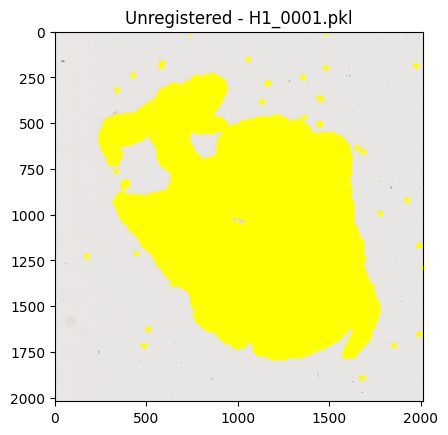

After adding padall (300): x=[468.8, 2311.7], y=[301.2, 2187.3]
Image size a (H,W): [2021 2014]
szA_xy (x,y offset): [583 116]
After adding szA: x=[1051.8, 2894.7], y=[417.2, 2303.3]
Recalculating affine transform from images...
Estimated transformation:
OpenCV matrix:
[[ 9.97491694e-01  7.02821559e-02 -1.57533858e+01]
 [-7.02821559e-02  9.97491694e-01  1.74398238e+02]]
MATLAB T matrix:
[[ 9.97491694e-01 -7.02821559e-02  0.00000000e+00]
 [ 7.02821559e-02  9.97491694e-01  0.00000000e+00]
 [-1.57533858e+01  1.74398238e+02  1.00000000e+00]]
Number of inliers: 100/100

--- Affine Transform ---
T matrix:
[[ 9.97491694e-01 -7.02821559e-02  0.00000000e+00]
 [ 7.02821559e-02  9.97491694e-01  0.00000000e+00]
 [-1.57533858e+01  1.74398238e+02  1.00000000e+00]]
cent: [1890.5 1427.5]
flipped: False
xy before transform: x=[1051.8, 2894.7], y=[417.2, 2303.3]
xyr after transform: x=[1053.0, 2895.4], y=[562.9, 2428.6]
Points after filtering: 235062


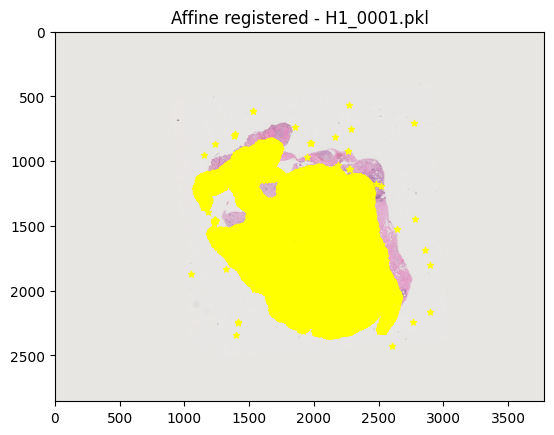


--- Elastic Transform ---
xytmp: x=[19075.8, 52452.3], y=[10198.1, 43997.1]
D shape (original): (571, 756, 2)
D shape (after resize): (2855, 3780, 2)
xmove range: x=[-907.8, 1793.3], y=[-1456.6, 139.0]
xye: x=[19145.3, 52677.8], y=[9780.0, 42540.5]


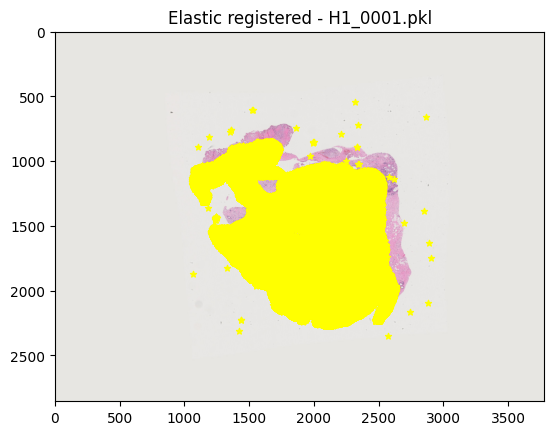

[1, 100, 235062, 235062] - H1_0001.pkl (with affine)
[2, 100, 228828, 228828] - H1_0004.pkl (with affine)
[3, 100, 231469, 231469] - H1_0007.pkl (with affine)


In [ ]:
ndpi_res=0.4416
vol_res=8
scale = vol_res/ndpi_res 
pth0 = r'\\kittyserverdw\Andre_kit\data\BTC\H1\1x_python' 
out_pth=r'\\kittyserverdw\Andre_kit\data\\BTC\H1\StarDist_8_28_2025_pdac'
pthcoords_pkl = os.path.join(out_pth, 'stardist_feature_df_pickles_classes')  # Path to pkl files with classes
outpthpkl_registered = os.path.join(out_pth, 'stardist_feature_df_pickles_classes_registered')
register_cell_coordinates_pointbased_monkey_centroids(pth0,
                                                    pthcoords_pkl,
                                                    scale)

In [4]:
out_pth

'\\\\kittyserverdw\\Andre_kit\\data\\BTC\\H1\\StarDist_8_28_2025_pdac'